<a href="https://colab.research.google.com/github/AlemayehuDabi/AI-ML/blob/main/intro_ml/magic_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

In [ ]:
cols = ["fLength", "fWidth", "fSize", "fConc", "fConc1", "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist", "class"]
df = pd.read_csv("/content/magic04.data", names=cols)
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [ ]:
df["class"].unique()

array(['g', 'h'], dtype=object)

In [ ]:
df["class"] = (df["class"] == "g").astype(int)

In [ ]:
pd.set_option('display.max_rows', None)
df.head(5)

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


/usr/local/lib/python3.12/dist-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


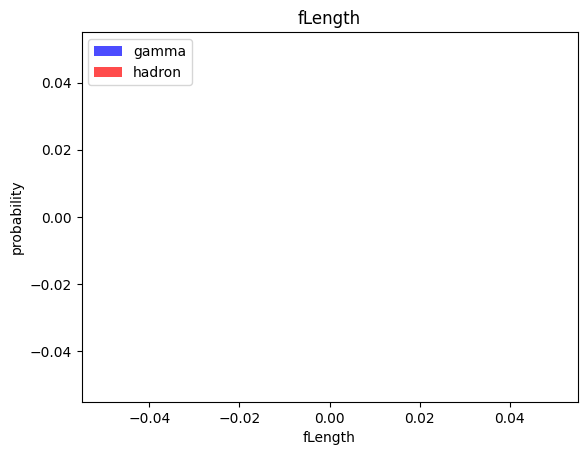

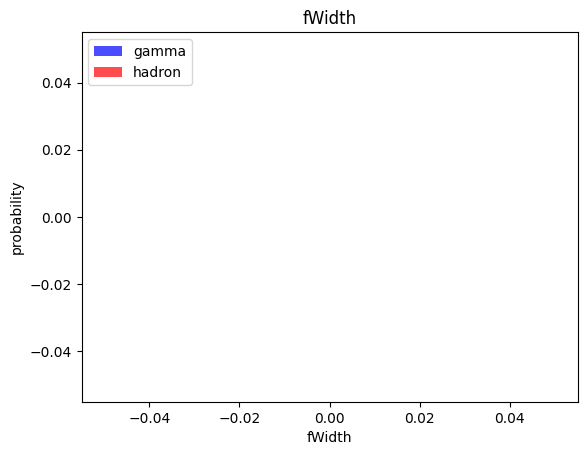

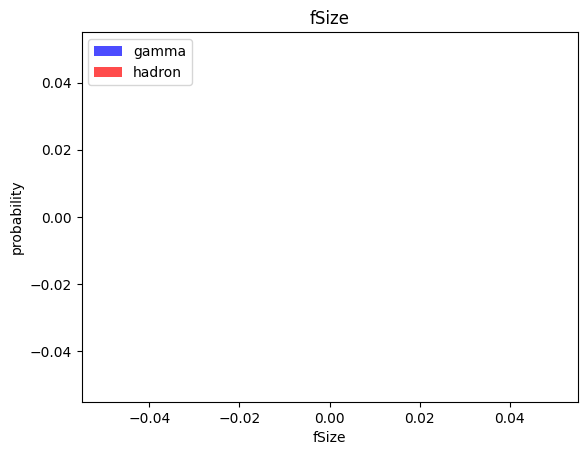

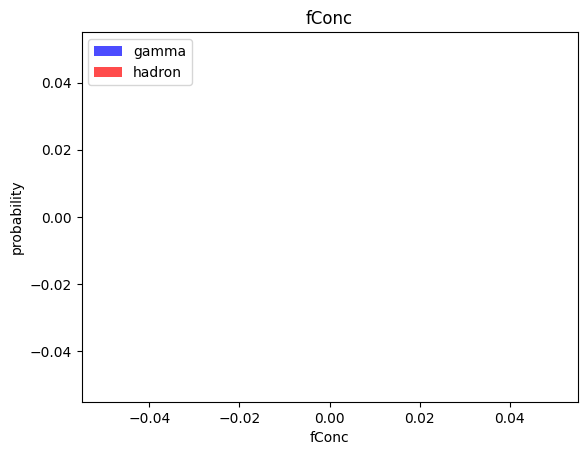

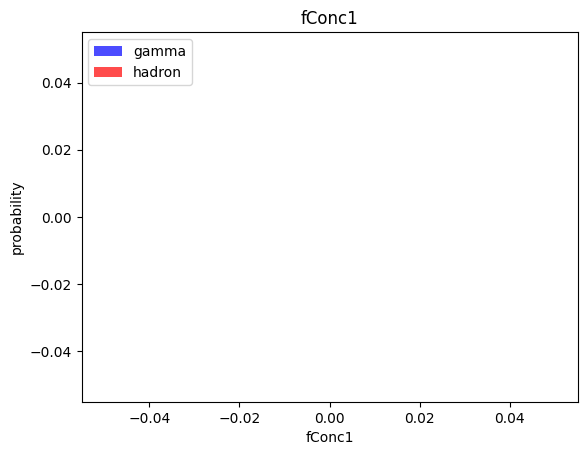

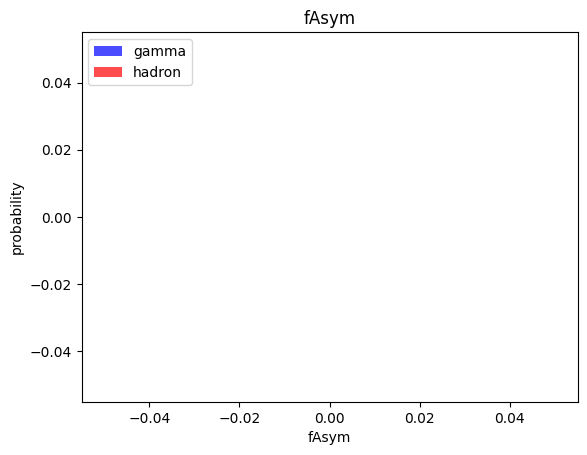

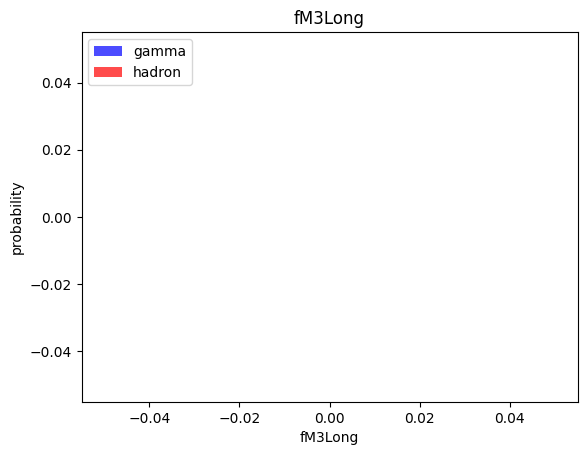

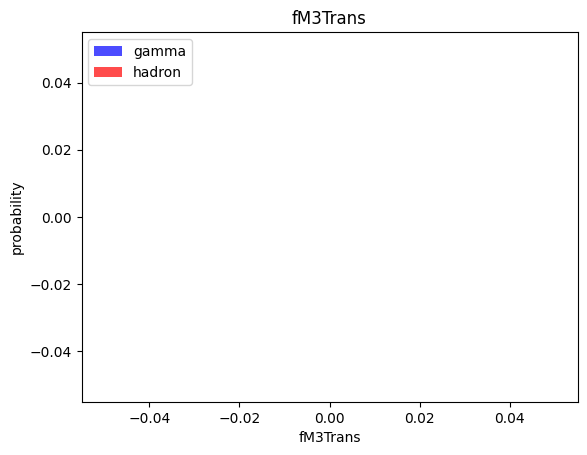

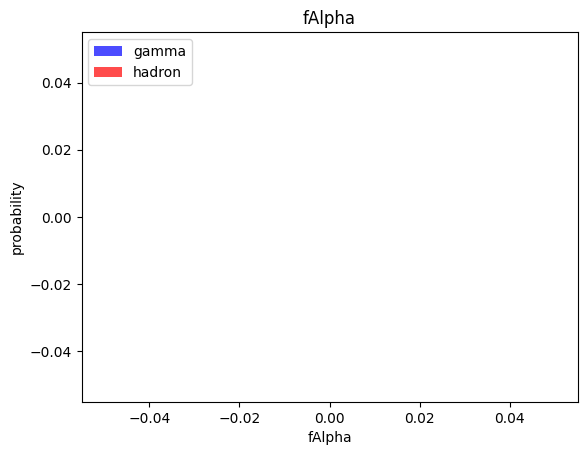

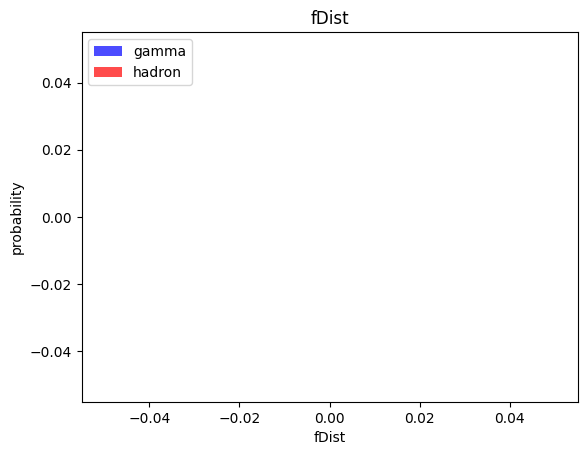

In [ ]:
for label in cols[:-1]:
  plt.hist(df[df["class"]==1][label], color="Blue", label="gamma", alpha=0.7, density=True)
  plt.hist(df[df["class"]==0][label], color="Red", label="hadron", alpha=0.7, density=True)
  plt.title(label)
  plt.xlabel(label)
  plt.ylabel("probability")
  plt.legend()
  plt.show()


Train, validation and testing datasets

In [ ]:
train, validation, test = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))])

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [ ]:
def scale_dataset(dataframe, over_sampling=False):
  X = df[df.columns[:-1]].values
  Y = df[df.columns[-1]].values

  scaler = StandardScaler()
  X = scaler.fit_transform(X)

  ros = RandomOverSampler()

  X, Y = ros.fit_resample(X,Y)

  data = np.hstack((X,np.reshape(Y, (-1,1))))

  return data, X, Y

In [ ]:
train, X_train, Y_train = scale_dataset(train, over_sampling=True)
validation, X_validation, Y_validation = scale_dataset(validation, over_sampling=False)
test, X_test, Y_test = scale_dataset(test, over_sampling=False)

# ***KNN***

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=10)
knn_model.fit(X_train, Y_train)

KNeighborsClassifier(n_neighbors=10)

In [ ]:
Y_predict = knn_model.predict(X_test)

In [ ]:
Y_predict

array([1, 0, 0, ..., 0, 1, 0])

In [ ]:
Y_test

array([1, 1, 1, ..., 0, 0, 0])

In [ ]:
print(classification_report(Y_test, Y_predict))

              precision    recall  f1-score   support

           0       0.88      0.84      0.86     12332
           1       0.84      0.88      0.86     12332

    accuracy                           0.86     24664
   macro avg       0.86      0.86      0.86     24664
weighted avg       0.86      0.86      0.86     24664



# ***NAVIE BAYES***

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
nb_model = GaussianNB()
nb_model =  nb_model.fit(X_train, Y_train)

In [ ]:
Y_predict = nb_model.predict(X_test)

In [ ]:
print(classification_report(Y_test, Y_predict))

              precision    recall  f1-score   support

           g       0.60      0.90      0.72     12332
           h       0.80      0.40      0.53     12332

    accuracy                           0.65     24664
   macro avg       0.70      0.65      0.63     24664
weighted avg       0.70      0.65      0.63     24664



# ***Logistic Regression***

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lg_model = LogisticRegression()
lg_model = lg_model.fit(X_train, Y_train)

In [ ]:
Y_predict = lg_model.predict(X_test)

In [ ]:
print(classification_report(Y_test, Y_predict))

              precision    recall  f1-score   support

           g       0.74      0.82      0.78     12332
           h       0.80      0.72      0.76     12332

    accuracy                           0.77     24664
   macro avg       0.77      0.77      0.77     24664
weighted avg       0.77      0.77      0.77     24664



# ***Support Vector Machine***

In [ ]:
from sklearn.svm import SVC

In [ ]:
svm_model = SVC()


In [ ]:
svm_model = svm_model.fit(X_train, Y_train)

In [ ]:
Y_predict = svm_model.predict(X_test)

In [ ]:
print(classification_report(Y_test, Y_predict))

              precision    recall  f1-score   support

           g       0.82      0.90      0.86     12332
           h       0.89      0.80      0.84     12332

    accuracy                           0.85     24664
   macro avg       0.86      0.85      0.85     24664
weighted avg       0.86      0.85      0.85     24664



# ***NN***

In [ ]:
import tensorflow as tf

In [ ]:
def plot_loss(history):
    """
    Plot training and validation loss from a TensorFlow History object.

    Usage:
        history = model.fit(...)
        plot_loss(history)
    """
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Training Loss')

    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss')

    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_accuracy(history):
    """
    Plot training and validation accuracy from a TensorFlow History object.

    Usage:
        history = model.fit(...)
        plot_accuracy(history)
    """
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['accuracy'], label='Training Accuracy')

    if 'val_accuracy' in history.history:
        plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# let define a function to alter the values easy and to find the best train and validation model.
def train_nn_model(X_train, Y_train, num_nodes, dropout, learning_rate, batch_size, epochs, validation_split=0.2):
  nn_model = tf.keras.Sequential([
      tf.keras.layers.Dense(num_nodes, activation='relu', input_shape=(10,)),
      tf.keras.layers.Dropout(dropout),
      tf.keras.layers.Dense(num_nodes,activation='relu'),
      tf.keras.layers.Dropout(dropout),
      tf.keras.layers.Dense(1,activation='sigmoid')
  ])

  nn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate), loss='binary_crossentropy', metrics=["accuracy"])

  # we are returning the history
  history = nn_model.fit(
      X_train, Y_train, epochs=epochs, validation_split=validation_split, verbose=0
  )

  return history, nn_model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


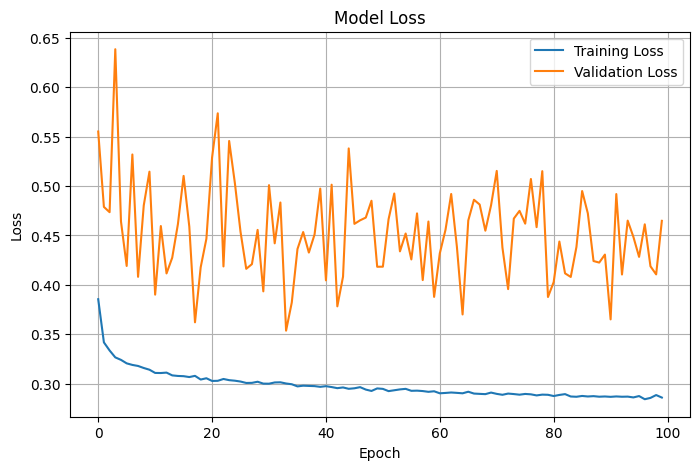

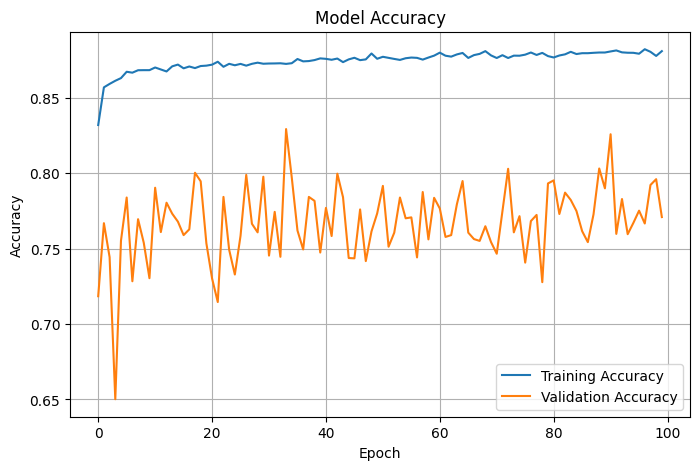

771/771 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8607 - loss: 0.3160
val loss: [0.3159685432910919, 0.8606876134872437]
val loss first number: 0.3159685432910919
Least valiation loss: 0.3159685432910919, Least loss model: <Sequential name=sequential_10, built=True>


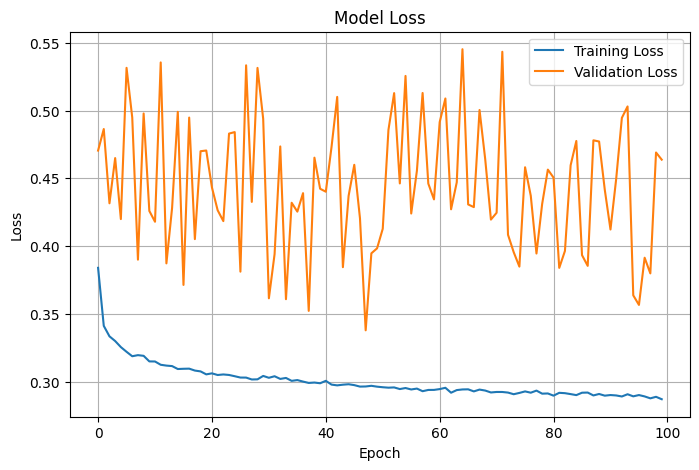

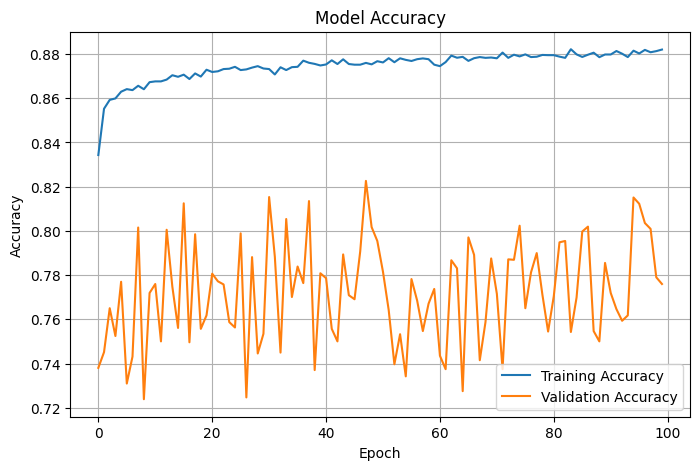

771/771 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8619 - loss: 0.3249
val loss: [0.32489678263664246, 0.8618634343147278]
val loss first number: 0.32489678263664246
Least valiation loss: 0.3159685432910919, Least loss model: <Sequential name=sequential_10, built=True>


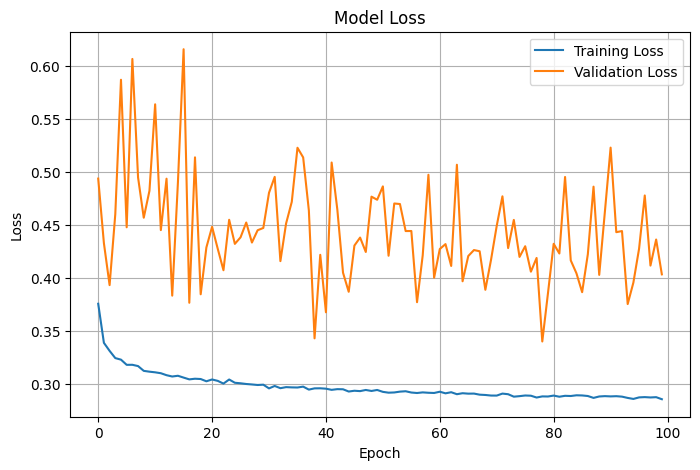

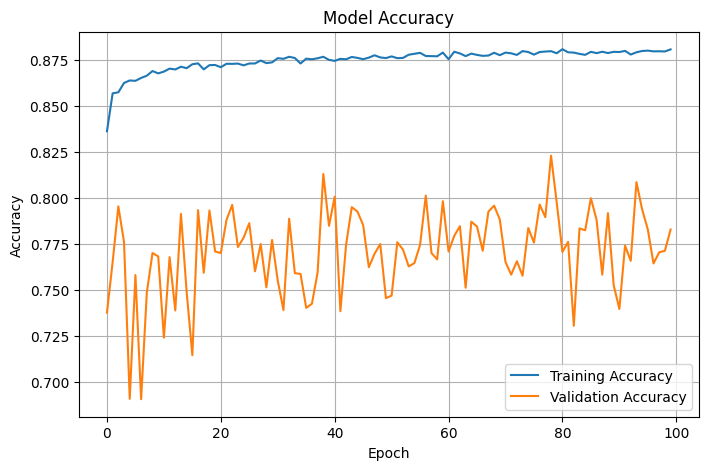

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8619 - loss: 0.3059
val loss: [0.30593469738960266, 0.861903965473175]
val loss first number: 0.30593469738960266
Least valiation loss: 0.30593469738960266, Least loss model: <Sequential name=sequential_12, built=True>


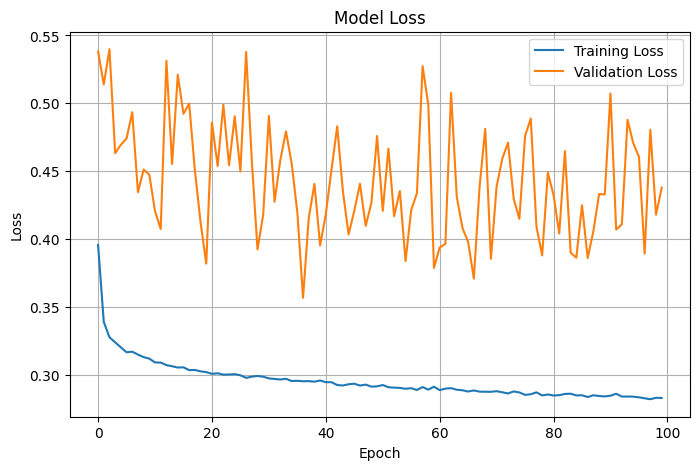

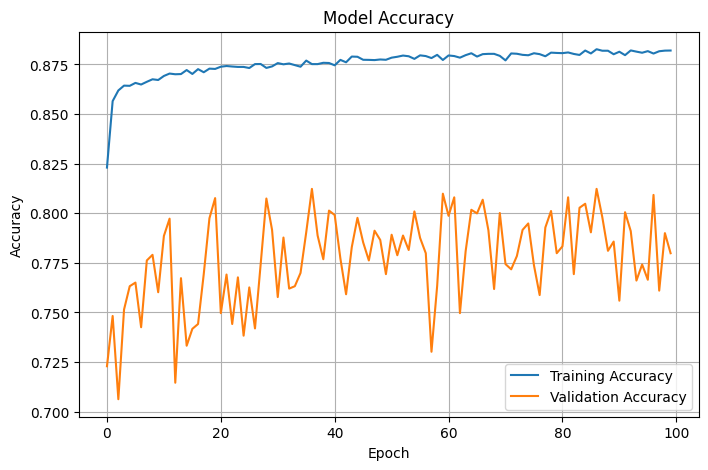

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8631 - loss: 0.3102
val loss: [0.3101593554019928, 0.8630797863006592]
val loss first number: 0.3101593554019928
Least valiation loss: 0.30593469738960266, Least loss model: <Sequential name=sequential_12, built=True>


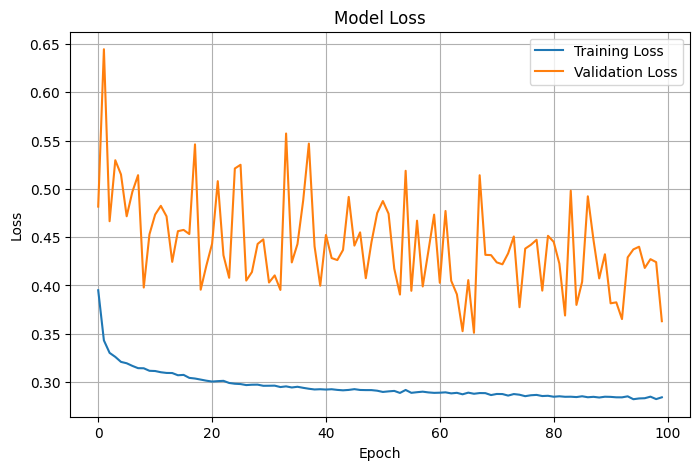

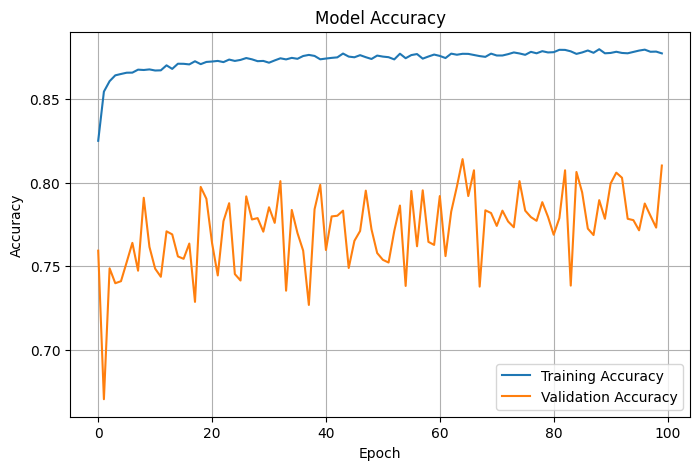

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8663 - loss: 0.2982
val loss: [0.29818761348724365, 0.8663234114646912]
val loss first number: 0.29818761348724365
Least valiation loss: 0.29818761348724365, Least loss model: <Sequential name=sequential_14, built=True>


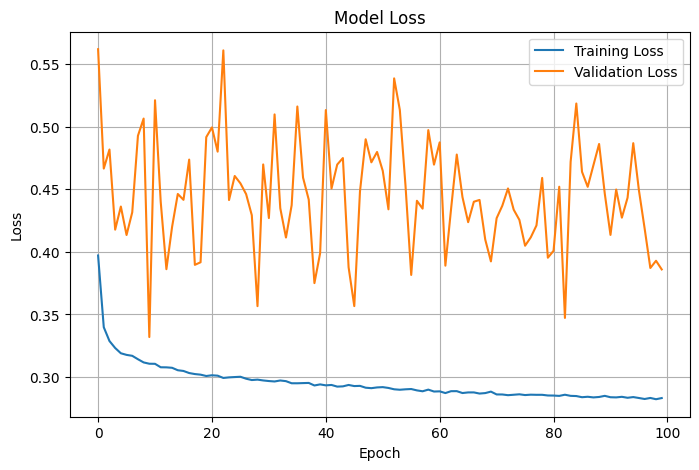

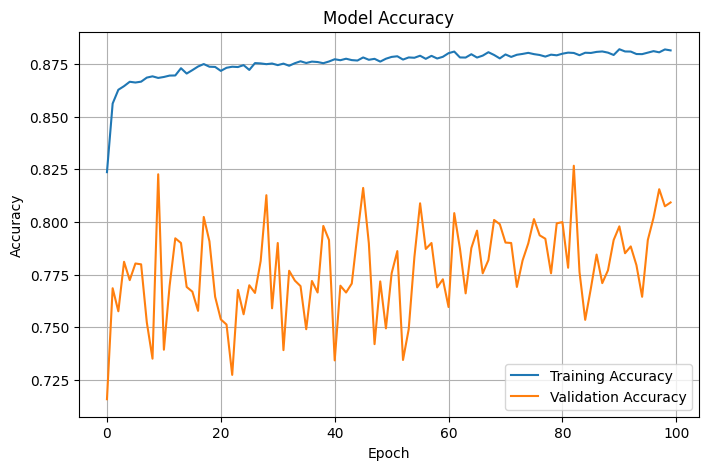

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8659 - loss: 0.3001
val loss: [0.3001350462436676, 0.8659179210662842]
val loss first number: 0.3001350462436676
Least valiation loss: 0.29818761348724365, Least loss model: <Sequential name=sequential_14, built=True>


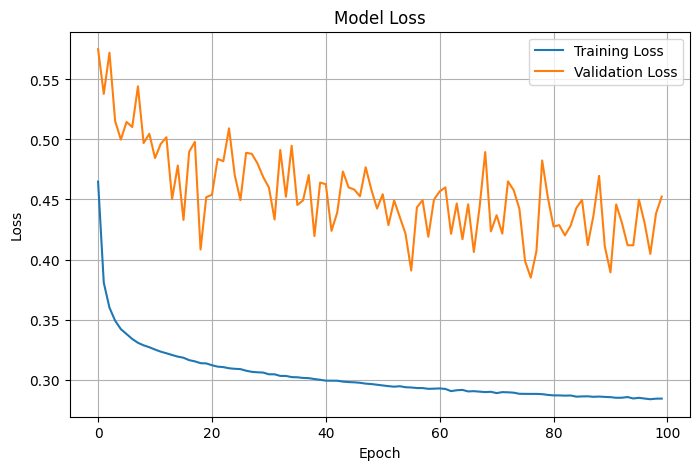

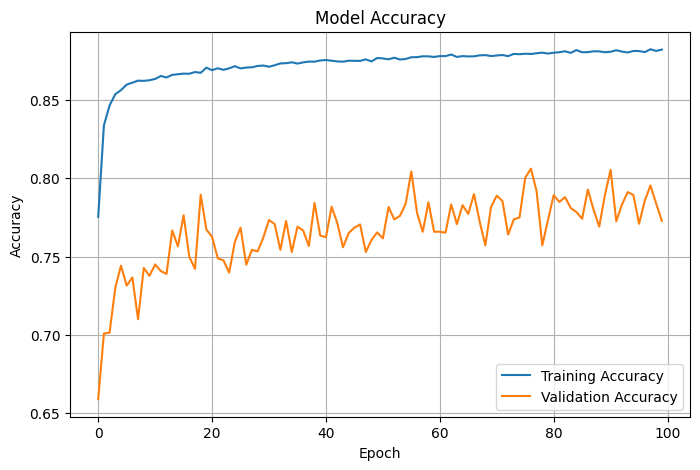

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8613 - loss: 0.3154
val loss: [0.3153502345085144, 0.8612958192825317]
val loss first number: 0.3153502345085144
Least valiation loss: 0.29818761348724365, Least loss model: <Sequential name=sequential_14, built=True>


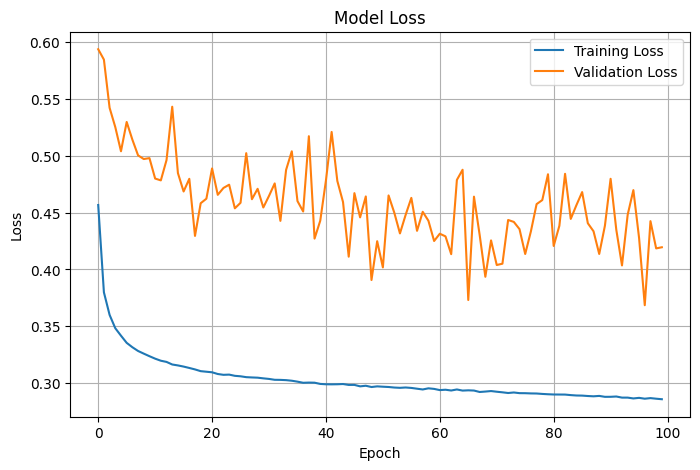

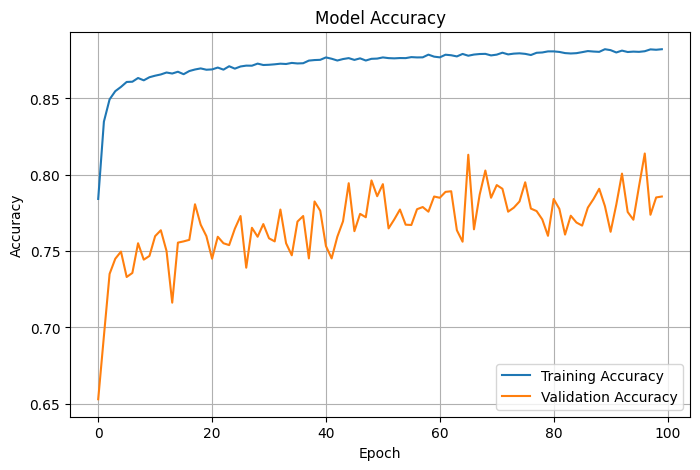

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8621 - loss: 0.3124
val loss: [0.3124229609966278, 0.8620661497116089]
val loss first number: 0.3124229609966278
Least valiation loss: 0.29818761348724365, Least loss model: <Sequential name=sequential_14, built=True>


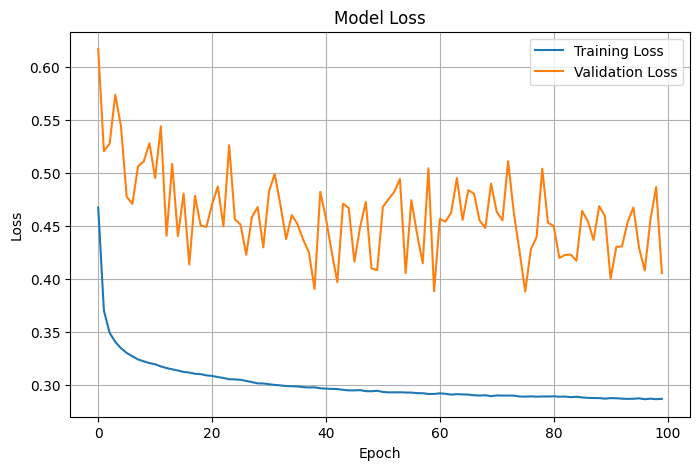

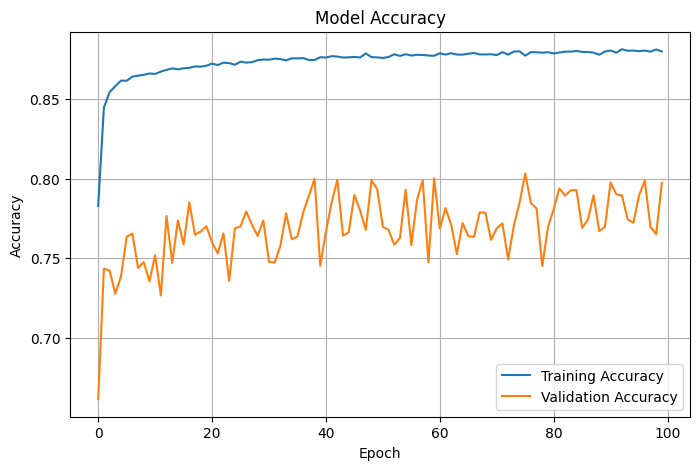

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8627 - loss: 0.3076
val loss: [0.3075803816318512, 0.862674355506897]
val loss first number: 0.3075803816318512
Least valiation loss: 0.29818761348724365, Least loss model: <Sequential name=sequential_14, built=True>


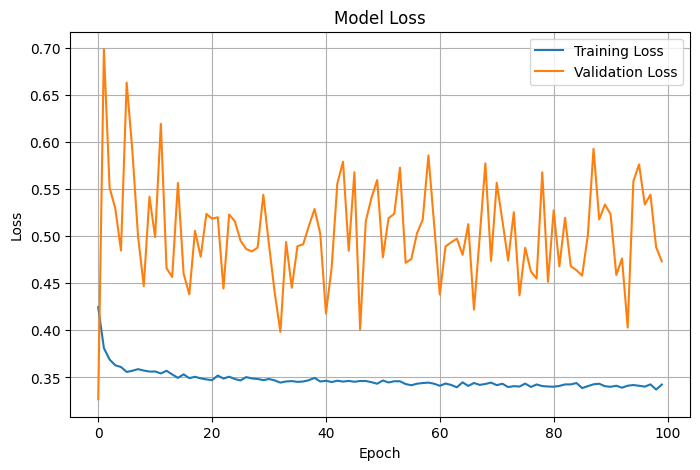

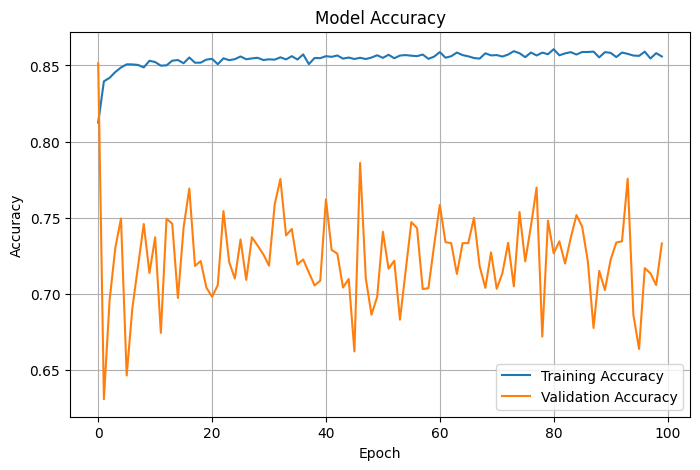

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8416 - loss: 0.3414
val loss: [0.3414399027824402, 0.8415910005569458]
val loss first number: 0.3414399027824402
Least valiation loss: 0.29818761348724365, Least loss model: <Sequential name=sequential_14, built=True>


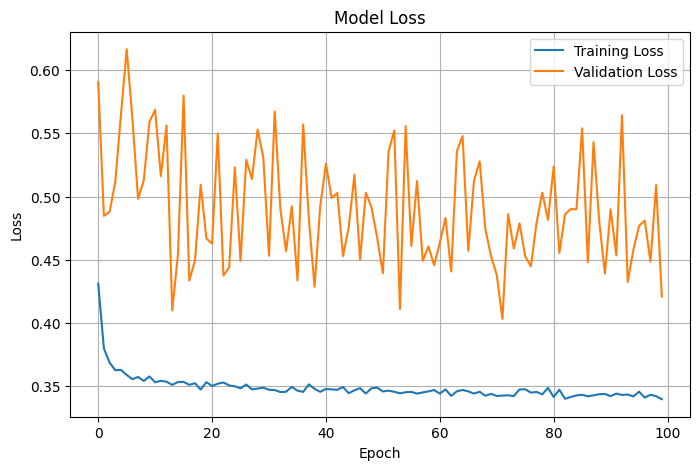

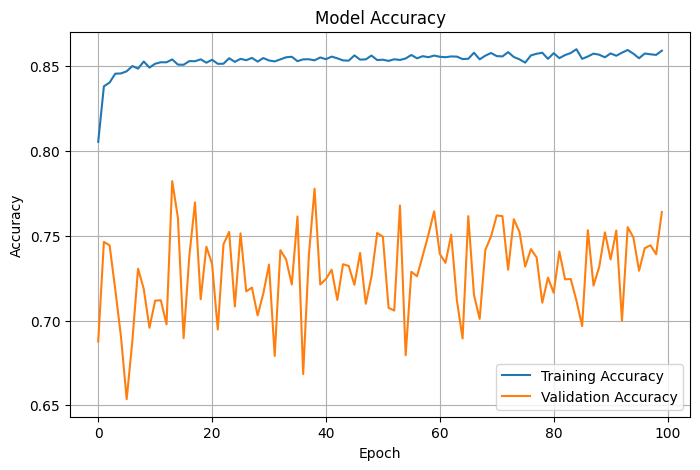

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8516 - loss: 0.3315
val loss: [0.3315485715866089, 0.8516461253166199]
val loss first number: 0.3315485715866089
Least valiation loss: 0.29818761348724365, Least loss model: <Sequential name=sequential_14, built=True>


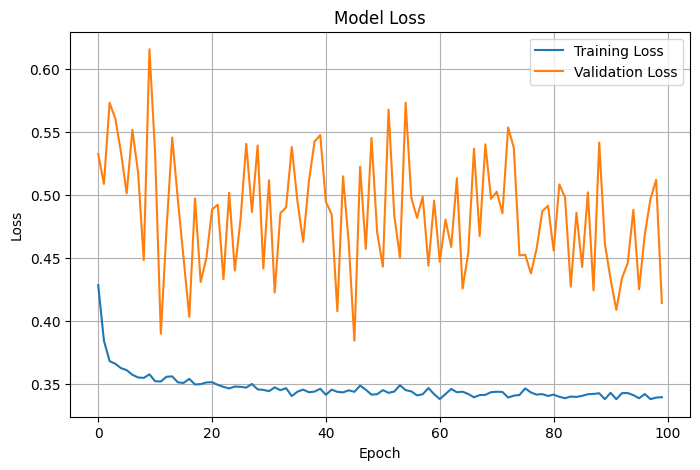

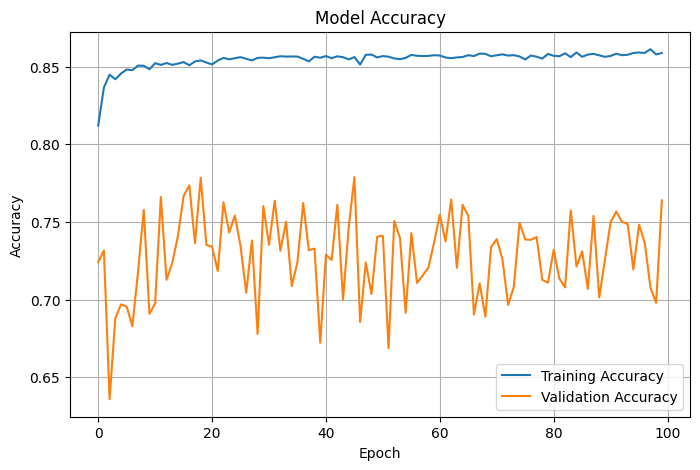

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8497 - loss: 0.3327
val loss: [0.33268803358078003, 0.8497405052185059]
val loss first number: 0.33268803358078003
Least valiation loss: 0.29818761348724365, Least loss model: <Sequential name=sequential_14, built=True>


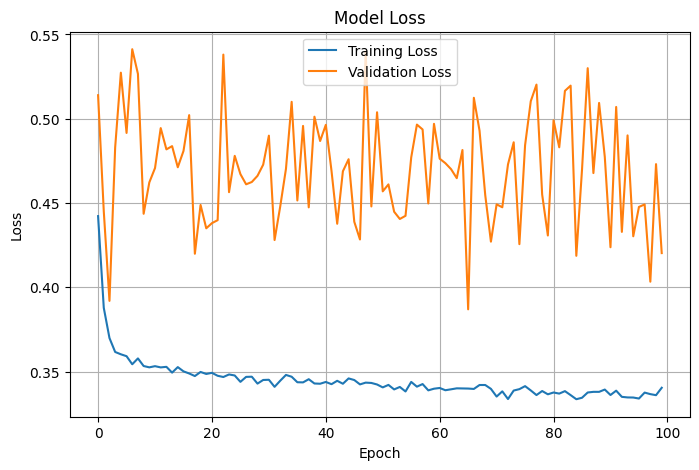

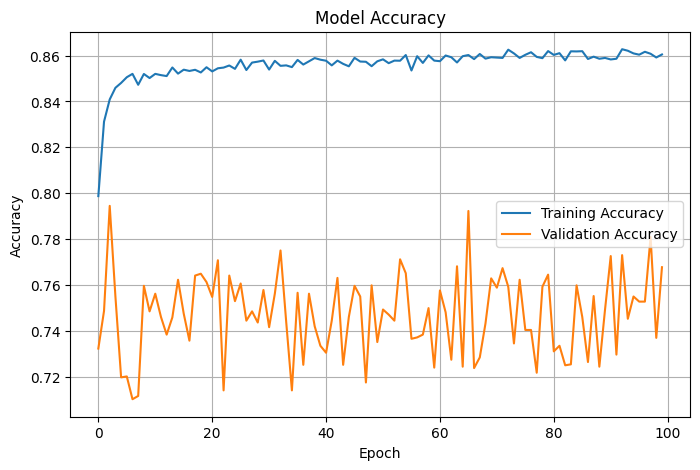

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8523 - loss: 0.3290
val loss: [0.329023152589798, 0.8522542715072632]
val loss first number: 0.329023152589798
Least valiation loss: 0.29818761348724365, Least loss model: <Sequential name=sequential_14, built=True>


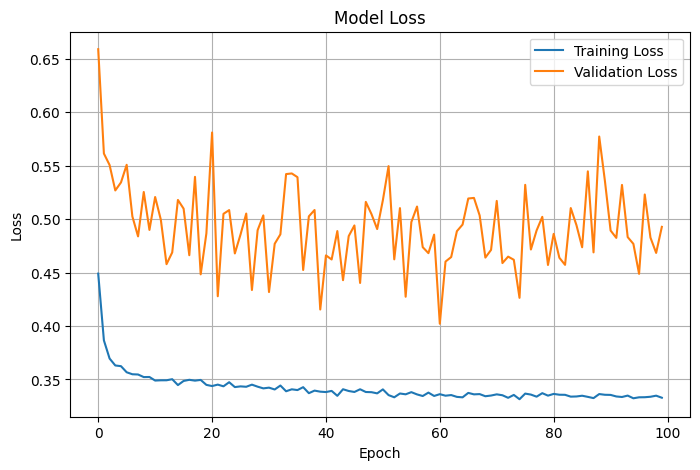

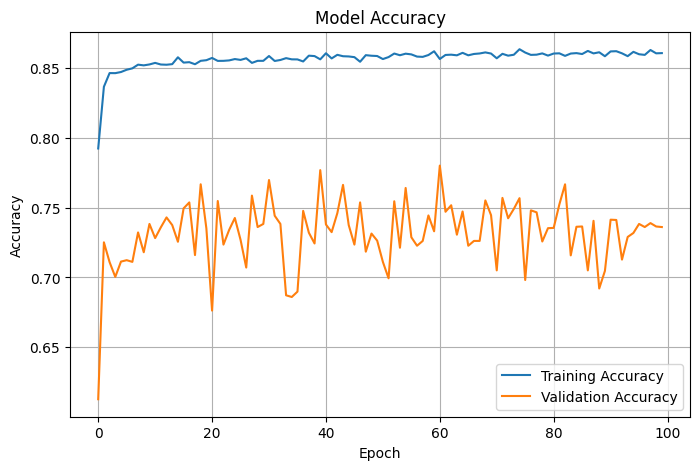

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8463 - loss: 0.3403
val loss: [0.3402668535709381, 0.8462941646575928]
val loss first number: 0.3402668535709381
Least valiation loss: 0.29818761348724365, Least loss model: <Sequential name=sequential_14, built=True>


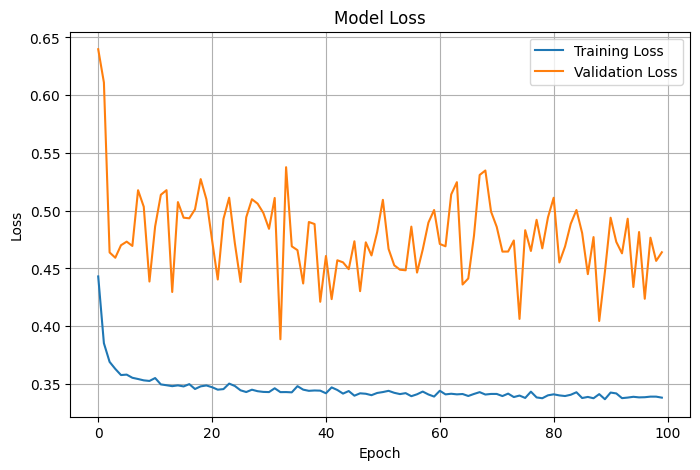

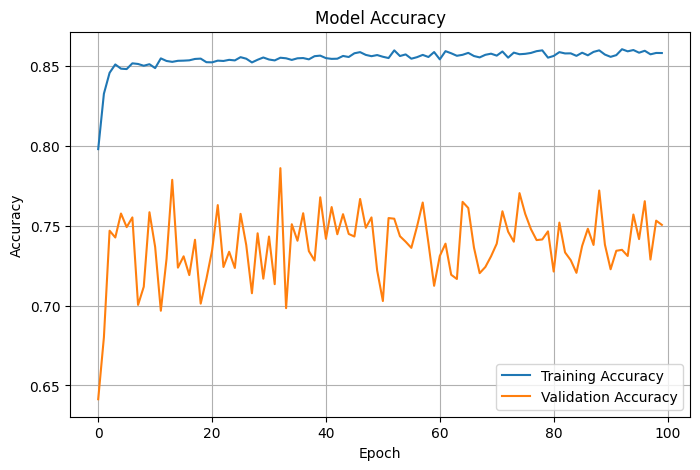

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8473 - loss: 0.3384
val loss: [0.3383972644805908, 0.8472672700881958]
val loss first number: 0.3383972644805908
Least valiation loss: 0.29818761348724365, Least loss model: <Sequential name=sequential_14, built=True>


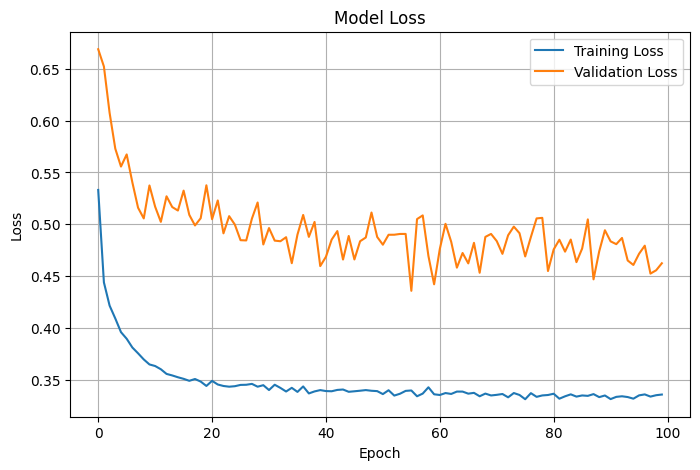

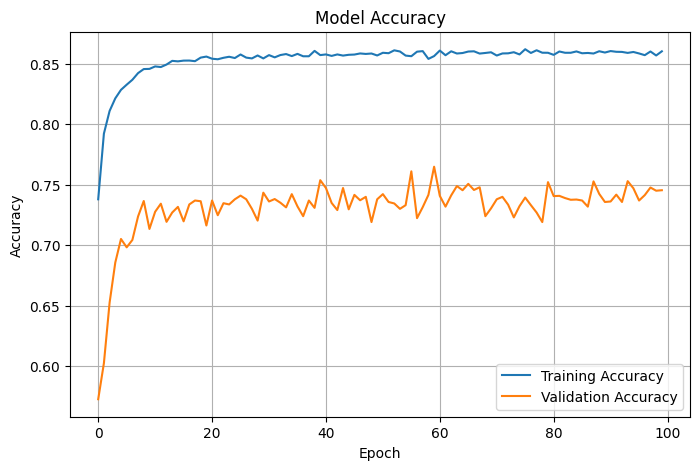

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8457 - loss: 0.3366
val loss: [0.3365614414215088, 0.8457265496253967]
val loss first number: 0.3365614414215088
Least valiation loss: 0.29818761348724365, Least loss model: <Sequential name=sequential_14, built=True>


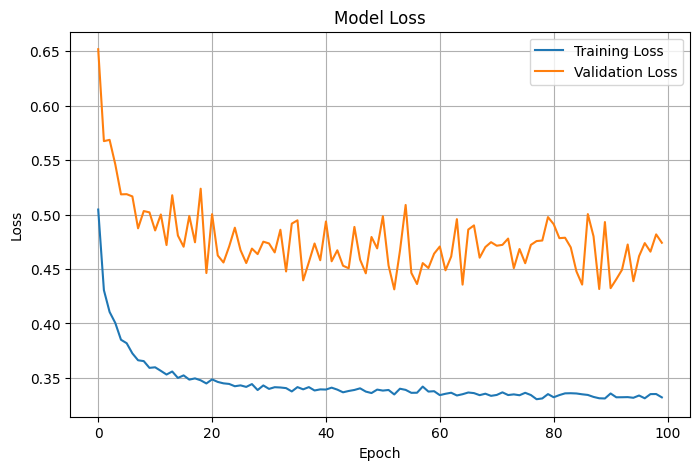

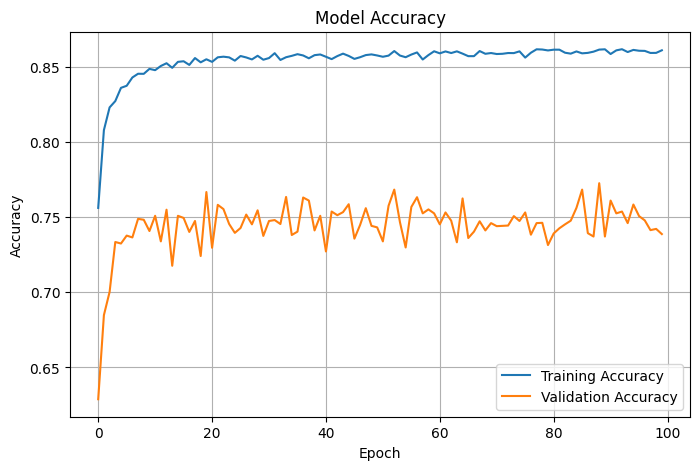

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8449 - loss: 0.3367
val loss: [0.3367019593715668, 0.8448750972747803]
val loss first number: 0.3367019593715668
Least valiation loss: 0.29818761348724365, Least loss model: <Sequential name=sequential_14, built=True>


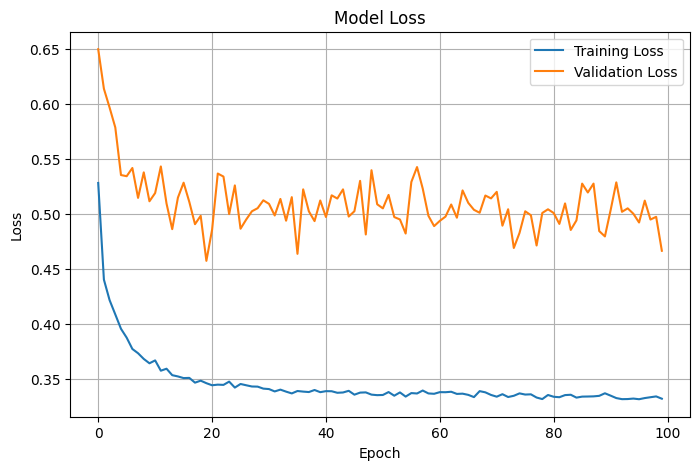

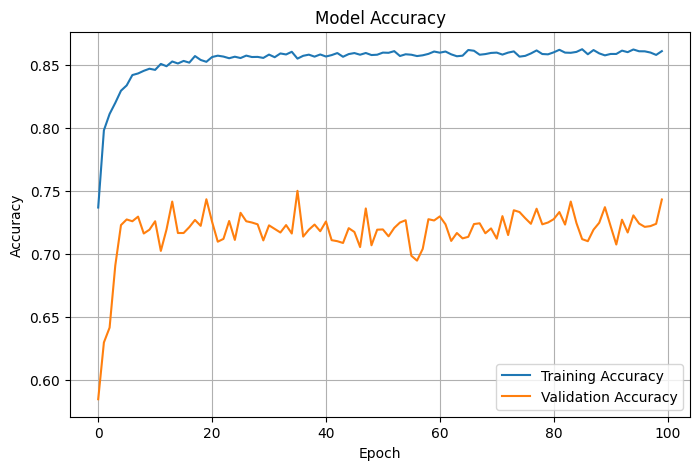

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8465 - loss: 0.3391
val loss: [0.33911240100860596, 0.8464563488960266]
val loss first number: 0.33911240100860596
Least valiation loss: 0.29818761348724365, Least loss model: <Sequential name=sequential_14, built=True>


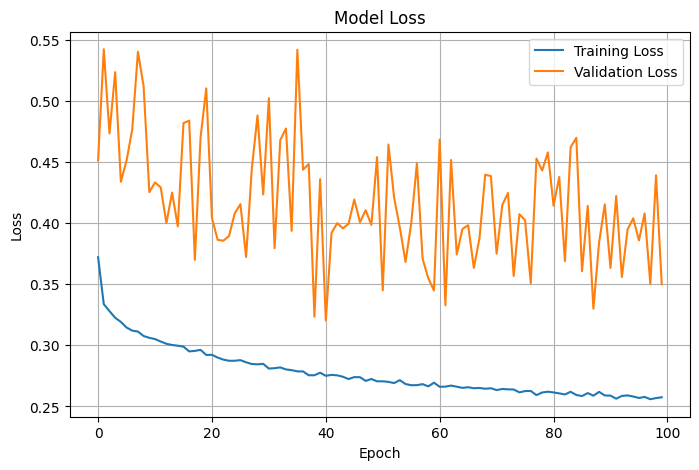

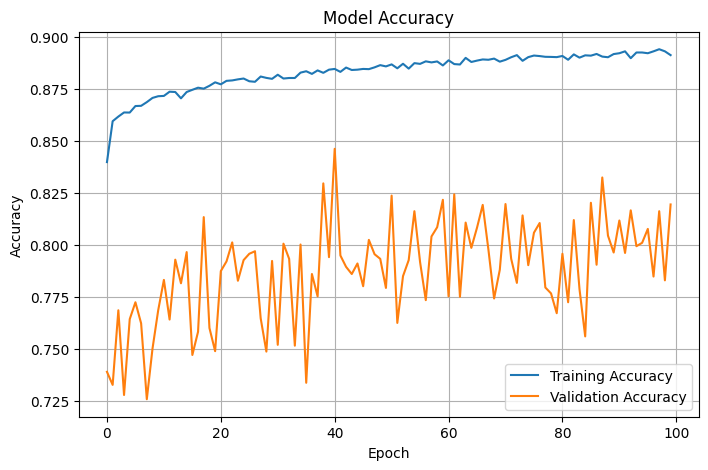

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8798 - loss: 0.2708
val loss: [0.27082541584968567, 0.8797842860221863]
val loss first number: 0.27082541584968567
Least valiation loss: 0.27082541584968567, Least loss model: <Sequential name=sequential_28, built=True>


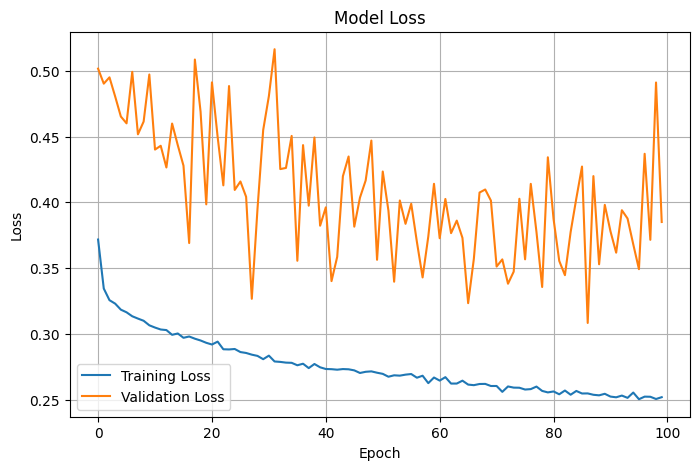

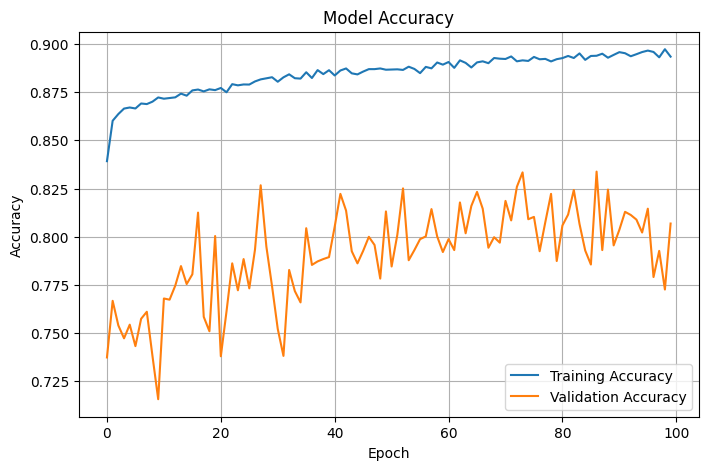

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8769 - loss: 0.2718
val loss: [0.2718021273612976, 0.8769461512565613]
val loss first number: 0.2718021273612976
Least valiation loss: 0.27082541584968567, Least loss model: <Sequential name=sequential_28, built=True>


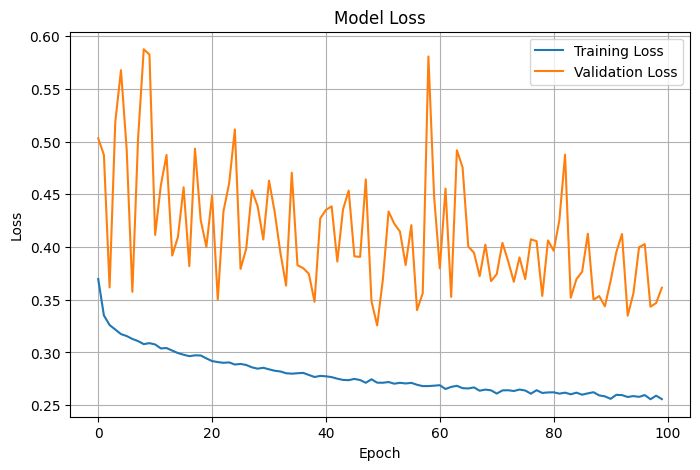

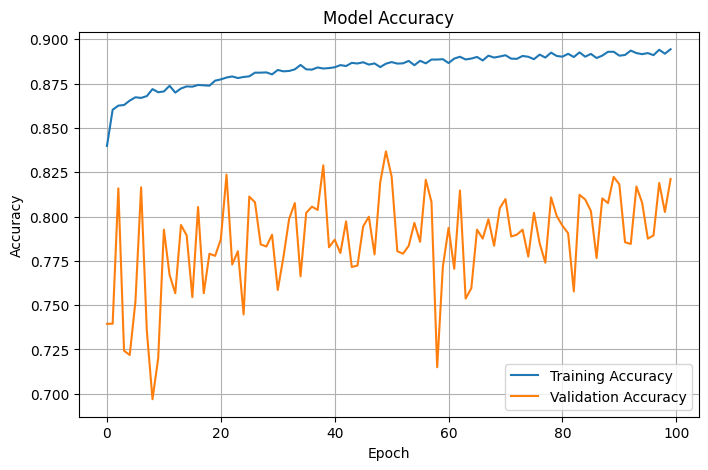

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8820 - loss: 0.2714
val loss: [0.2713669240474701, 0.8819737434387207]
val loss first number: 0.2713669240474701
Least valiation loss: 0.27082541584968567, Least loss model: <Sequential name=sequential_28, built=True>


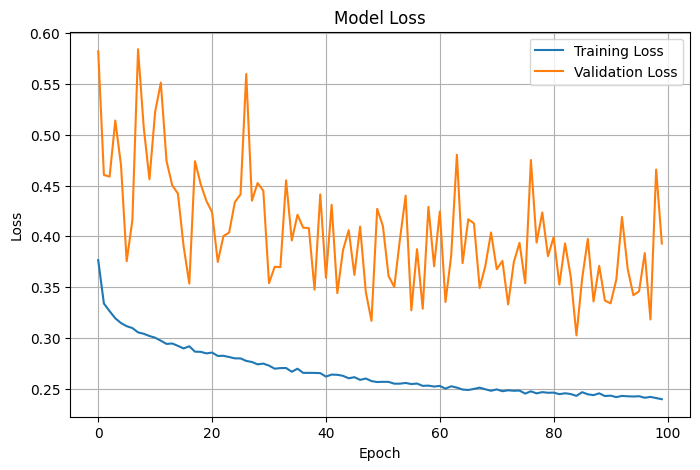

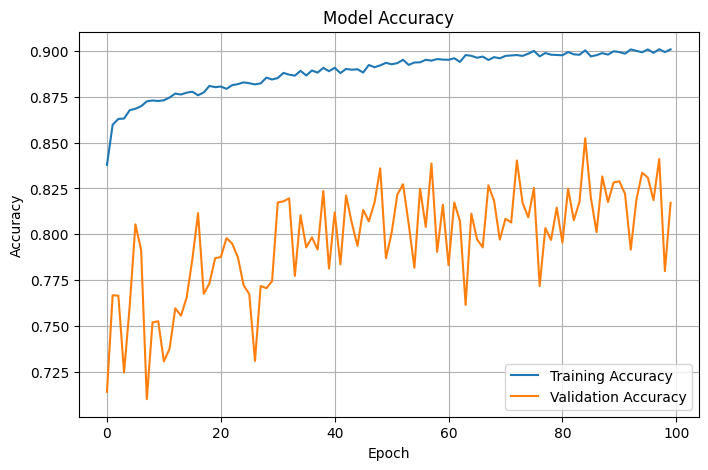

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8861 - loss: 0.2675
val loss: [0.26749417185783386, 0.8860687613487244]
val loss first number: 0.26749417185783386
Least valiation loss: 0.26749417185783386, Least loss model: <Sequential name=sequential_31, built=True>


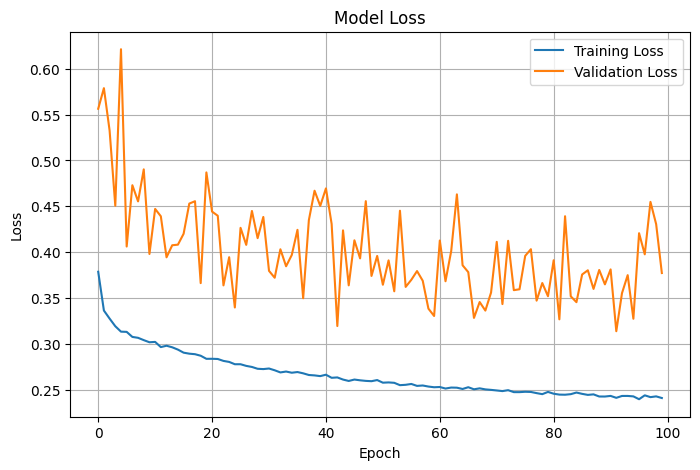

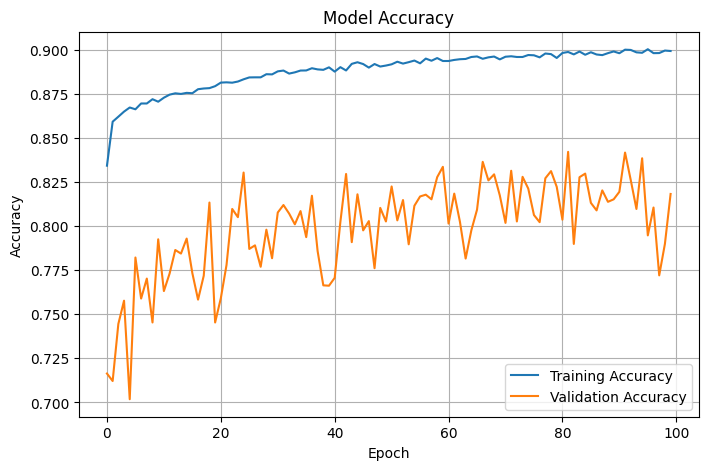

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8868 - loss: 0.2648
val loss: [0.2647543251514435, 0.8868390917778015]
val loss first number: 0.2647543251514435
Least valiation loss: 0.2647543251514435, Least loss model: <Sequential name=sequential_32, built=True>


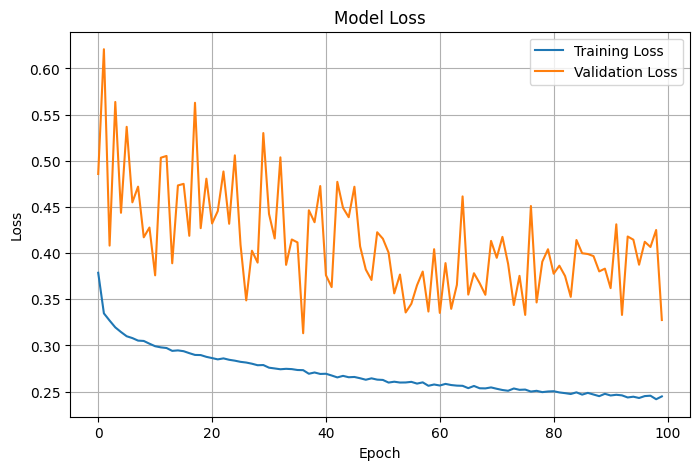

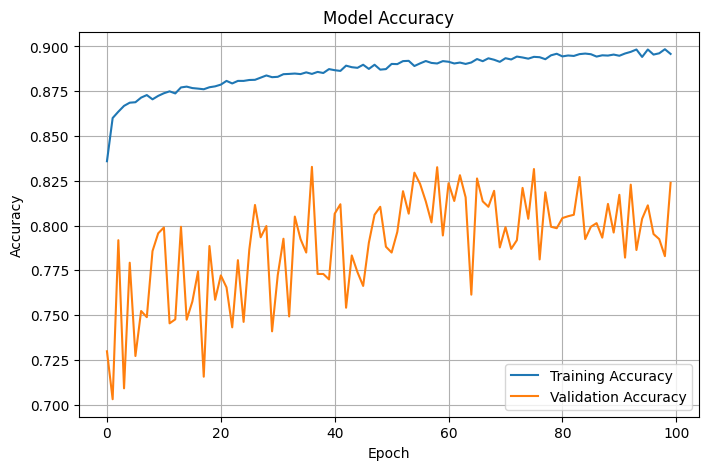

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8832 - loss: 0.2583
val loss: [0.25829991698265076, 0.8831900954246521]
val loss first number: 0.25829991698265076
Least valiation loss: 0.25829991698265076, Least loss model: <Sequential name=sequential_33, built=True>


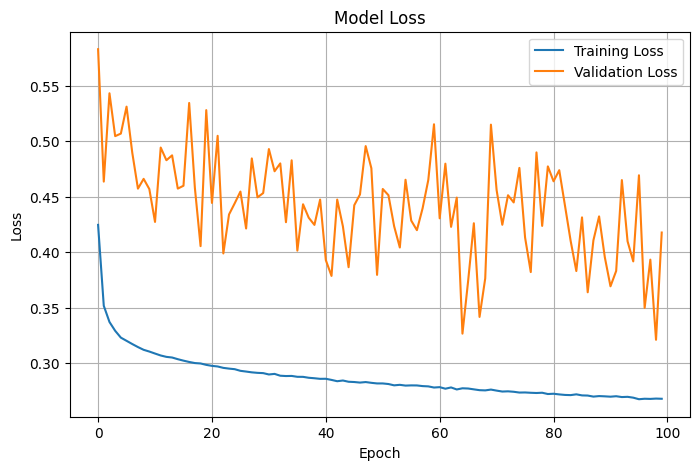

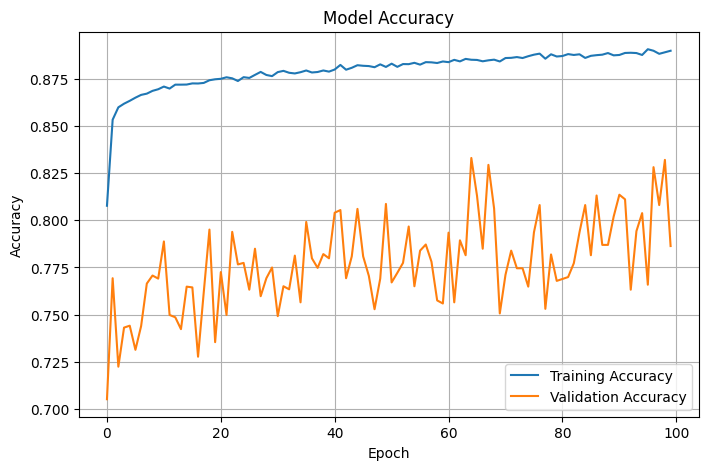

771/771 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8681 - loss: 0.2948
val loss: [0.29480448365211487, 0.8681479096412659]
val loss first number: 0.29480448365211487
Least valiation loss: 0.25829991698265076, Least loss model: <Sequential name=sequential_33, built=True>


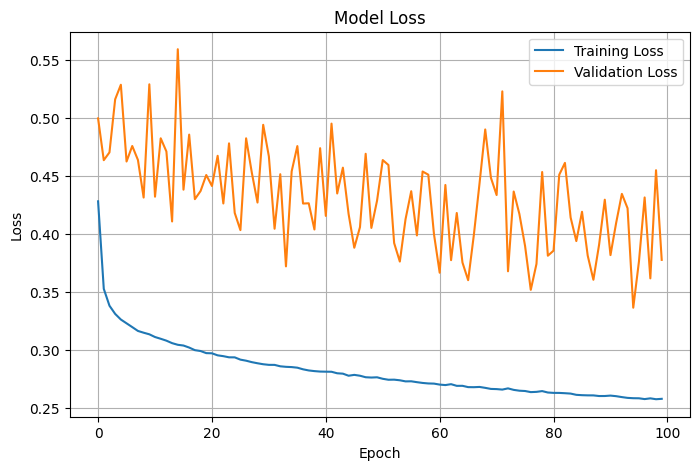

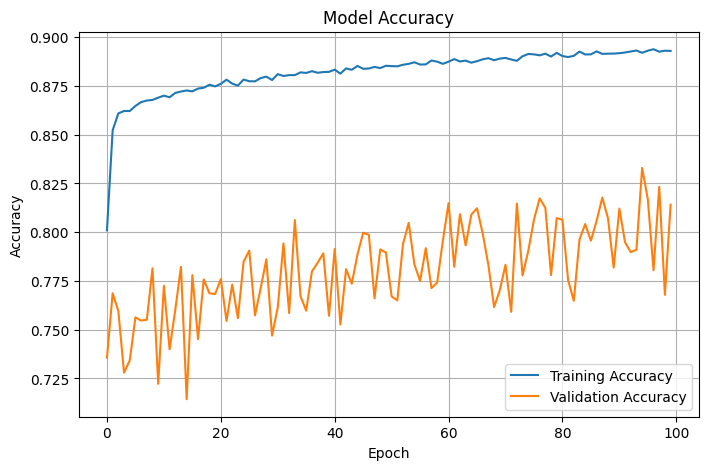

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8780 - loss: 0.2779
val loss: [0.27789491415023804, 0.8779597878456116]
val loss first number: 0.27789491415023804
Least valiation loss: 0.25829991698265076, Least loss model: <Sequential name=sequential_33, built=True>


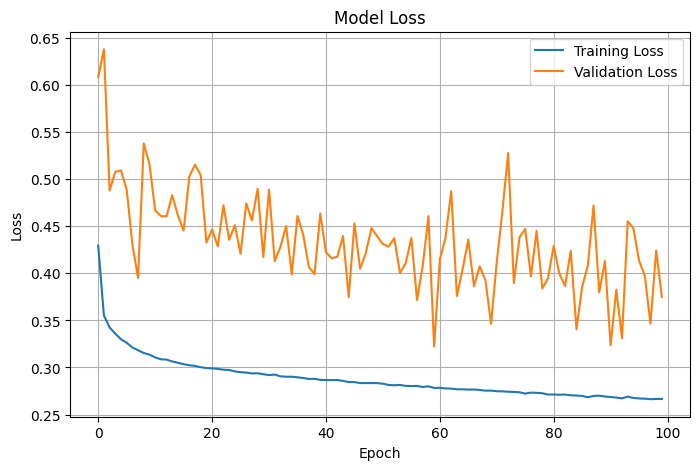

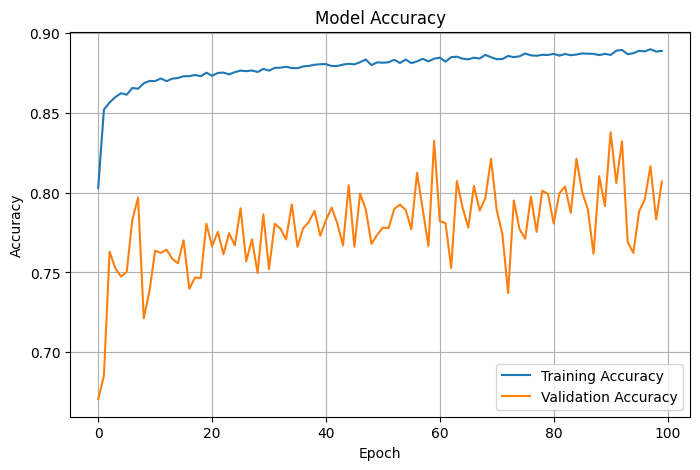

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8736 - loss: 0.2828
val loss: [0.2827785015106201, 0.8736214637756348]
val loss first number: 0.2827785015106201
Least valiation loss: 0.25829991698265076, Least loss model: <Sequential name=sequential_33, built=True>


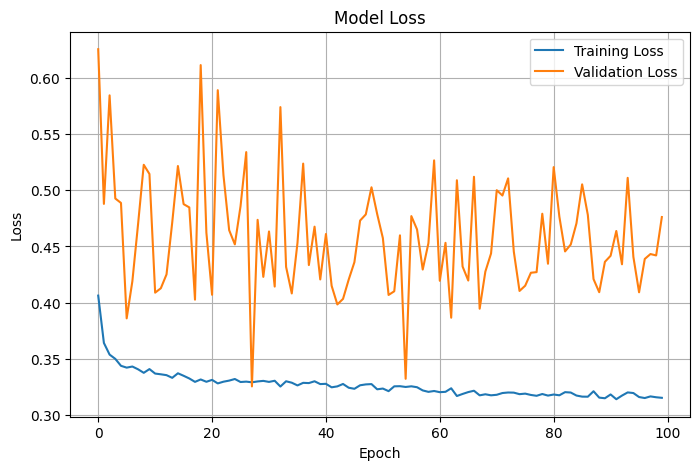

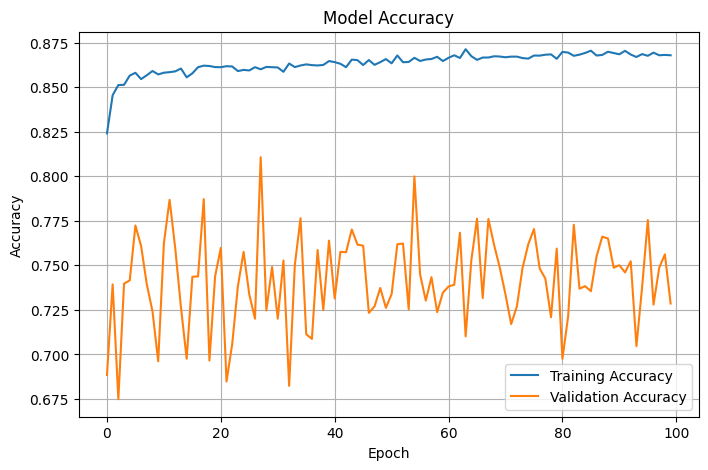

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8465 - loss: 0.3286
val loss: [0.3285776376724243, 0.8464563488960266]
val loss first number: 0.3285776376724243
Least valiation loss: 0.25829991698265076, Least loss model: <Sequential name=sequential_33, built=True>


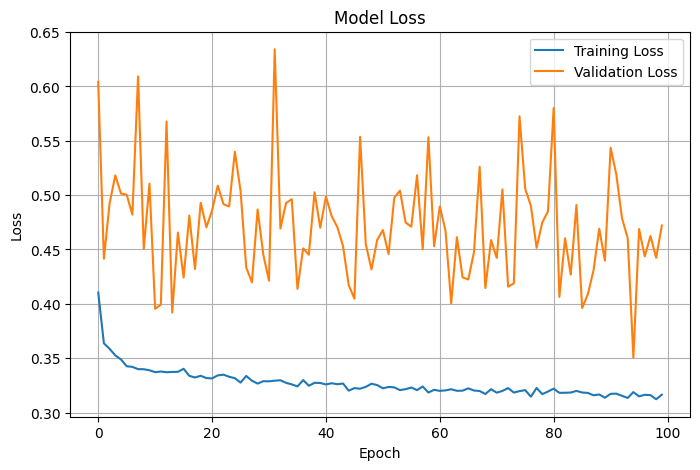

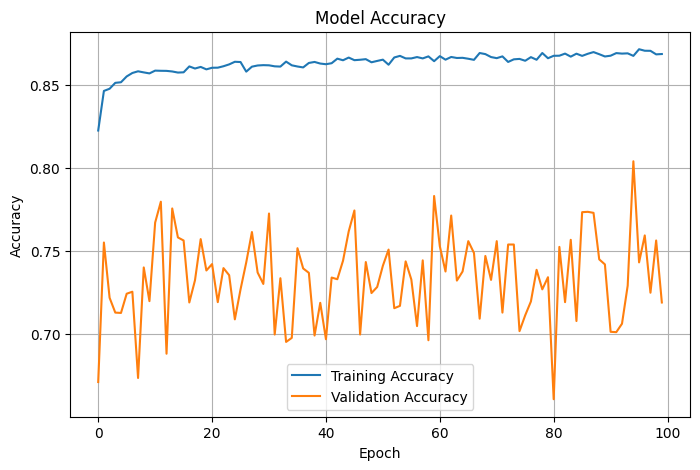

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8433 - loss: 0.3379
val loss: [0.3378901481628418, 0.843334436416626]
val loss first number: 0.3378901481628418
Least valiation loss: 0.25829991698265076, Least loss model: <Sequential name=sequential_33, built=True>


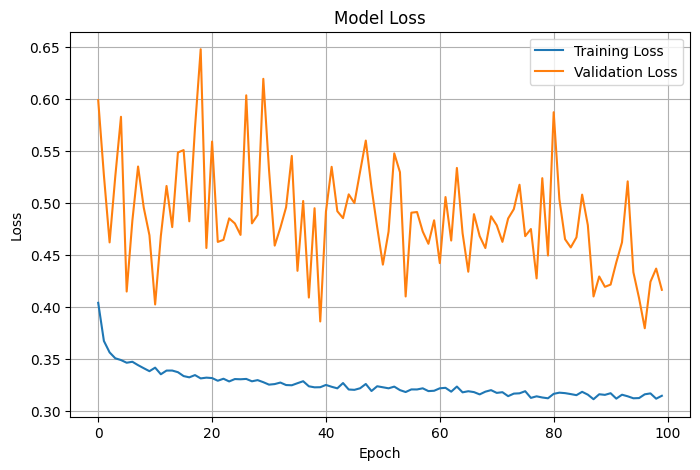

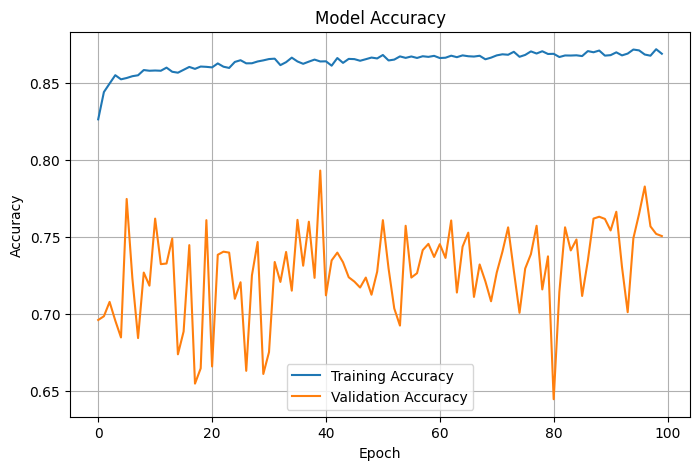

771/771 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8535 - loss: 0.3150
val loss: [0.3150210976600647, 0.8534706234931946]
val loss first number: 0.3150210976600647
Least valiation loss: 0.25829991698265076, Least loss model: <Sequential name=sequential_33, built=True>


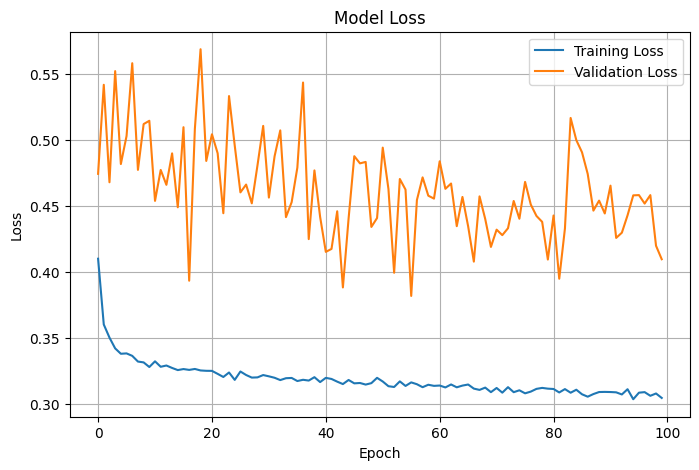

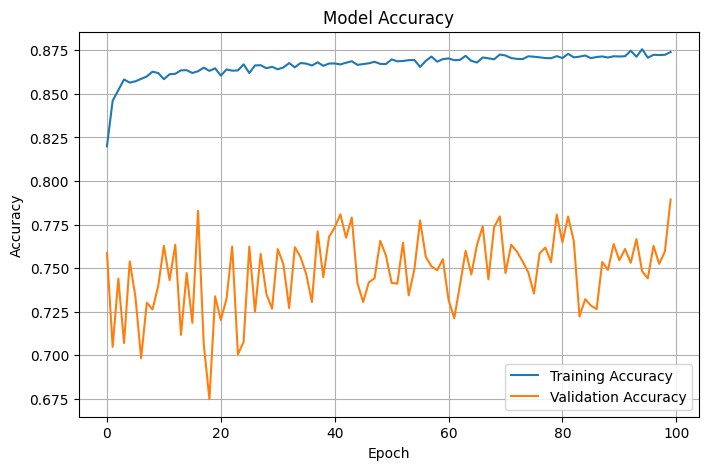

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8635 - loss: 0.3048
val loss: [0.3048097491264343, 0.8634852170944214]
val loss first number: 0.3048097491264343
Least valiation loss: 0.25829991698265076, Least loss model: <Sequential name=sequential_33, built=True>


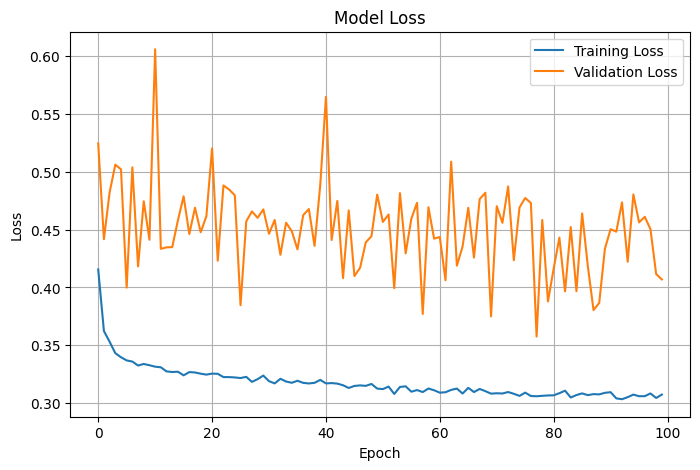

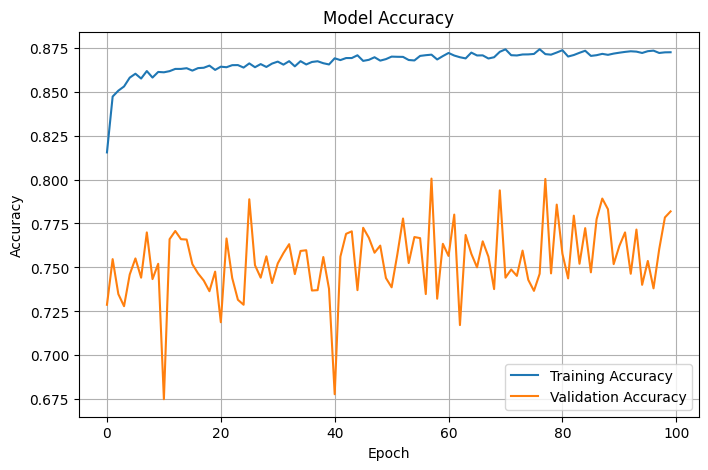

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8630 - loss: 0.3048
val loss: [0.30479633808135986, 0.8630392551422119]
val loss first number: 0.30479633808135986
Least valiation loss: 0.25829991698265076, Least loss model: <Sequential name=sequential_33, built=True>


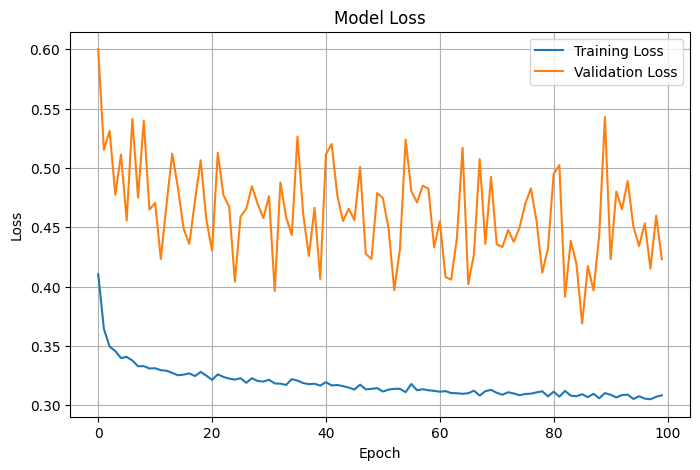

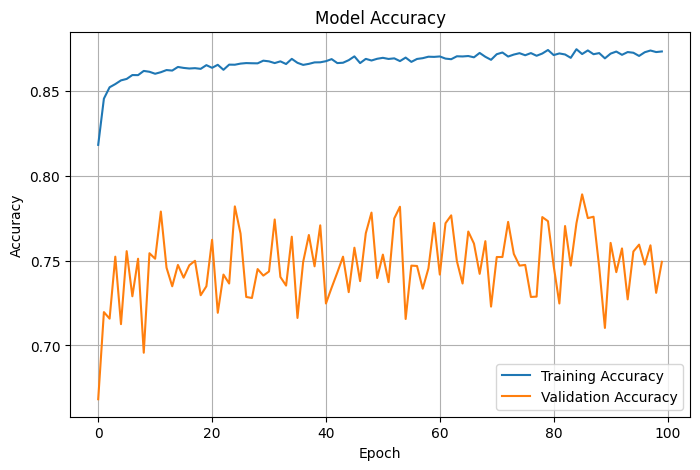

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8509 - loss: 0.3166
val loss: [0.31656208634376526, 0.85091632604599]
val loss first number: 0.31656208634376526
Least valiation loss: 0.25829991698265076, Least loss model: <Sequential name=sequential_33, built=True>


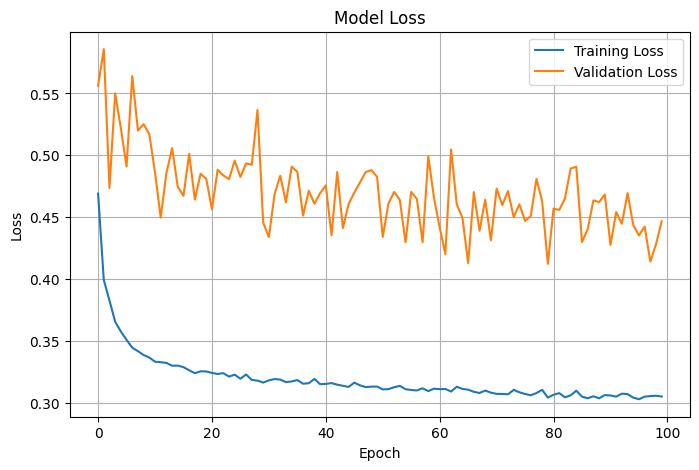

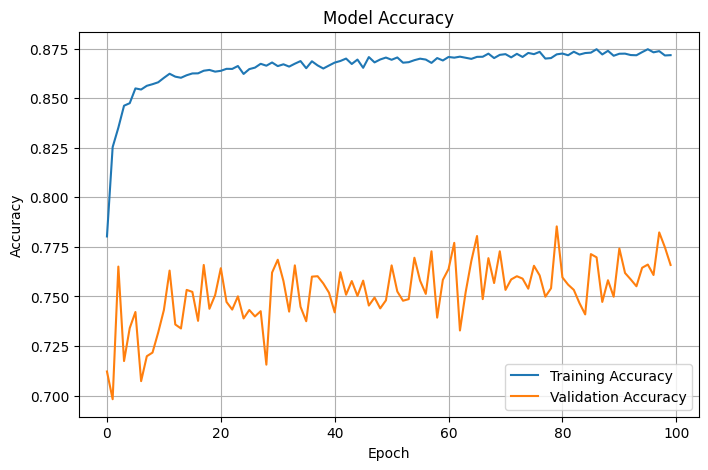

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8592 - loss: 0.3136
val loss: [0.31359440088272095, 0.8592280149459839]
val loss first number: 0.31359440088272095
Least valiation loss: 0.25829991698265076, Least loss model: <Sequential name=sequential_33, built=True>


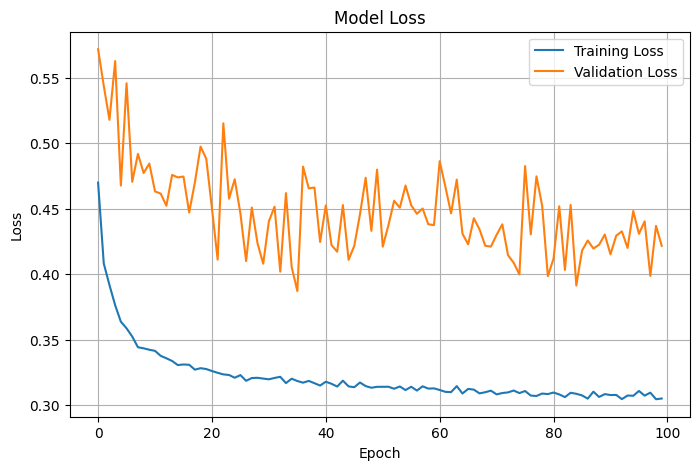

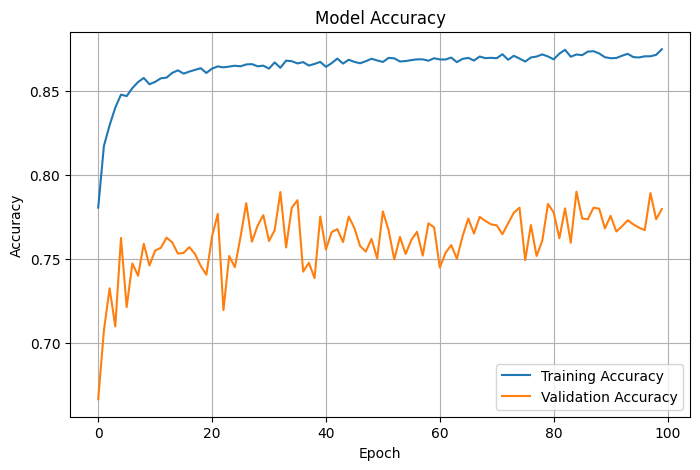

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8606 - loss: 0.3107
val loss: [0.3106648921966553, 0.8605660200119019]
val loss first number: 0.3106648921966553
Least valiation loss: 0.25829991698265076, Least loss model: <Sequential name=sequential_33, built=True>


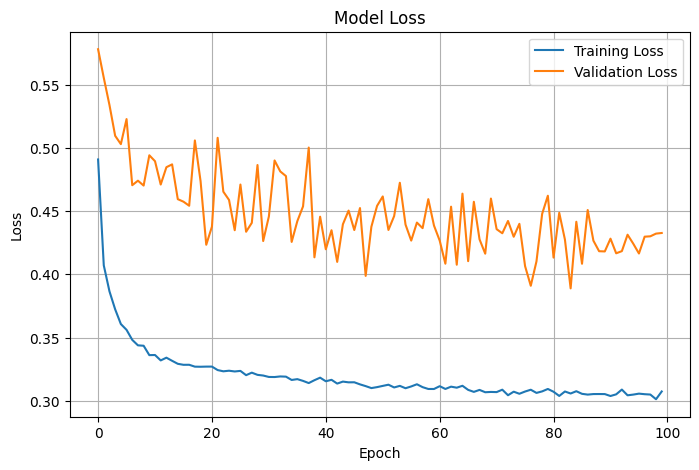

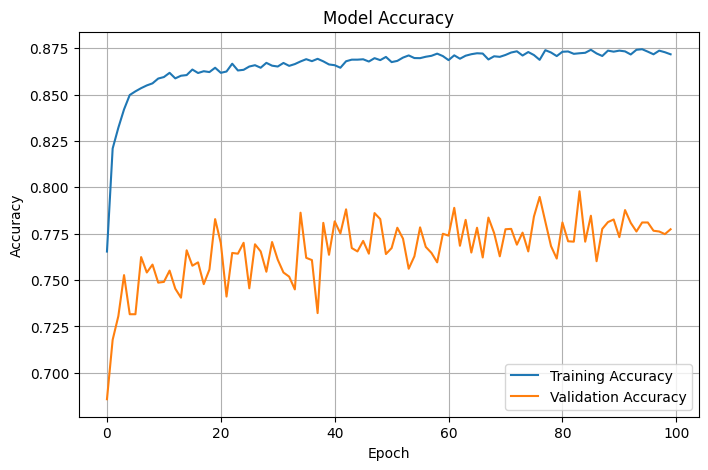

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8611 - loss: 0.3127
val loss: [0.3126567602157593, 0.8610931038856506]
val loss first number: 0.3126567602157593
Least valiation loss: 0.25829991698265076, Least loss model: <Sequential name=sequential_33, built=True>


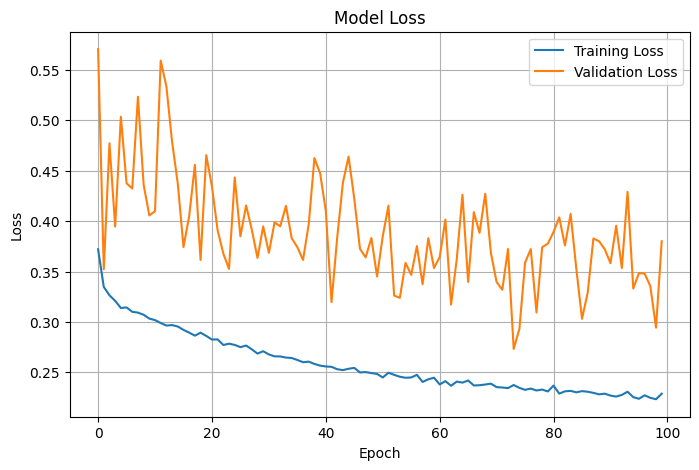

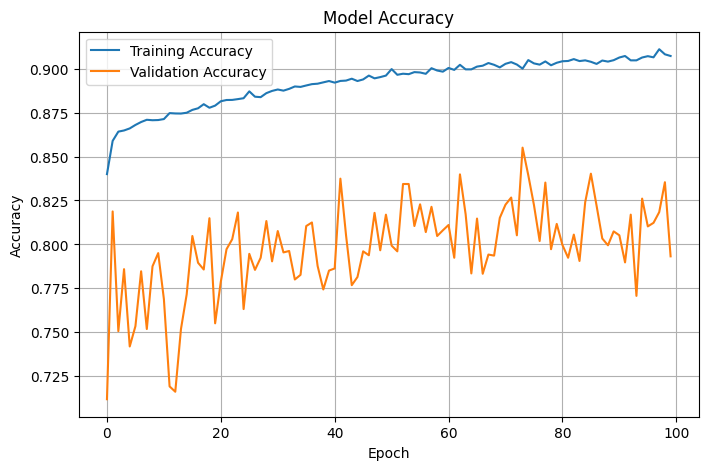

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8841 - loss: 0.2574
val loss: [0.25735023617744446, 0.8841226100921631]
val loss first number: 0.25735023617744446
Least valiation loss: 0.25735023617744446, Least loss model: <Sequential name=sequential_46, built=True>


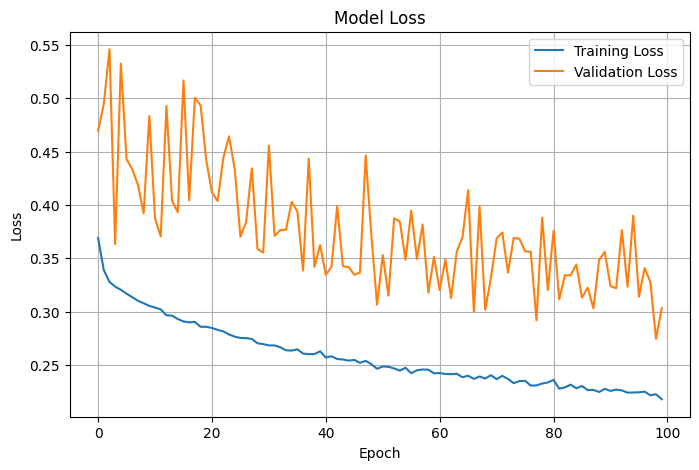

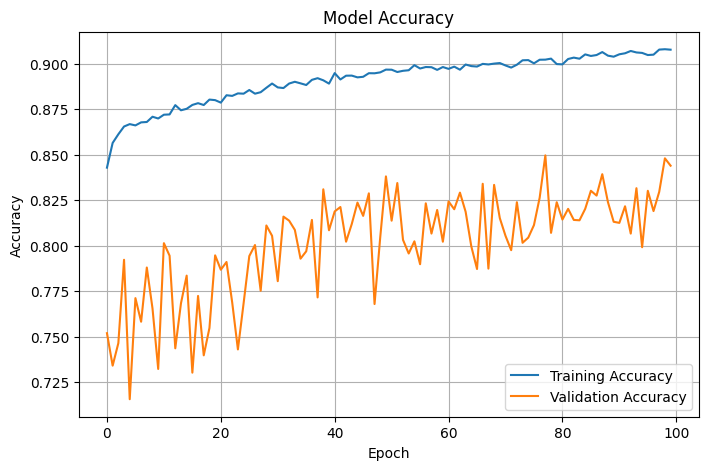

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8926 - loss: 0.2397
val loss: [0.23970651626586914, 0.8925964832305908]
val loss first number: 0.23970651626586914
Least valiation loss: 0.23970651626586914, Least loss model: <Sequential name=sequential_47, built=True>


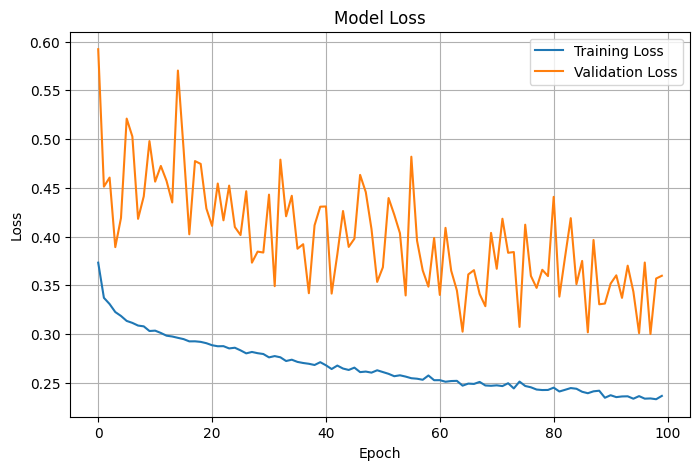

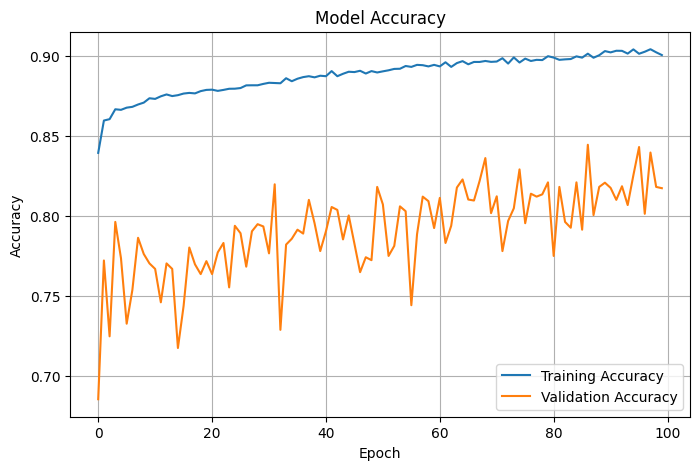

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8857 - loss: 0.2554
val loss: [0.2553555965423584, 0.8857038617134094]
val loss first number: 0.2553555965423584
Least valiation loss: 0.23970651626586914, Least loss model: <Sequential name=sequential_47, built=True>


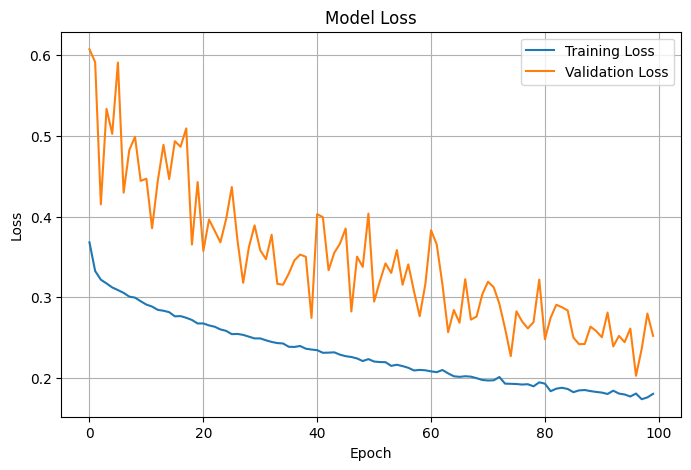

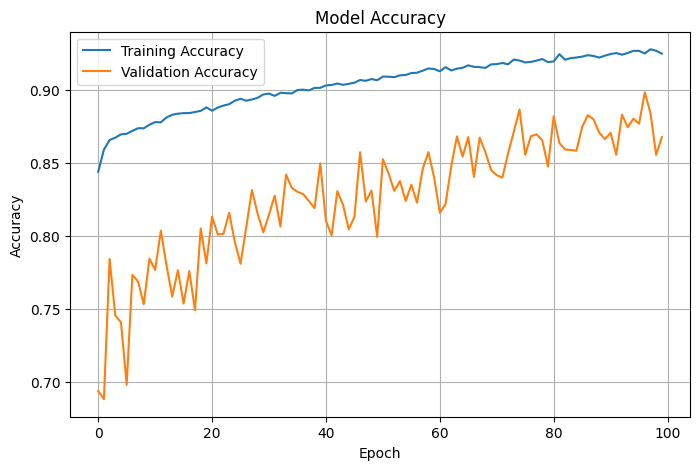

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9171 - loss: 0.1840
val loss: [0.1840384602546692, 0.9170856475830078]
val loss first number: 0.1840384602546692
Least valiation loss: 0.1840384602546692, Least loss model: <Sequential name=sequential_49, built=True>


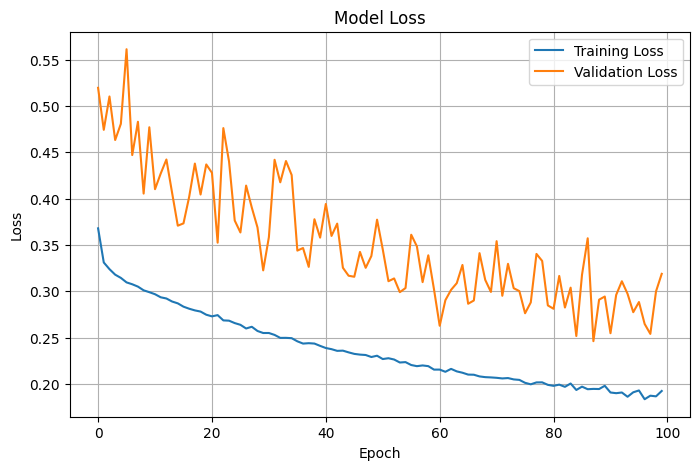

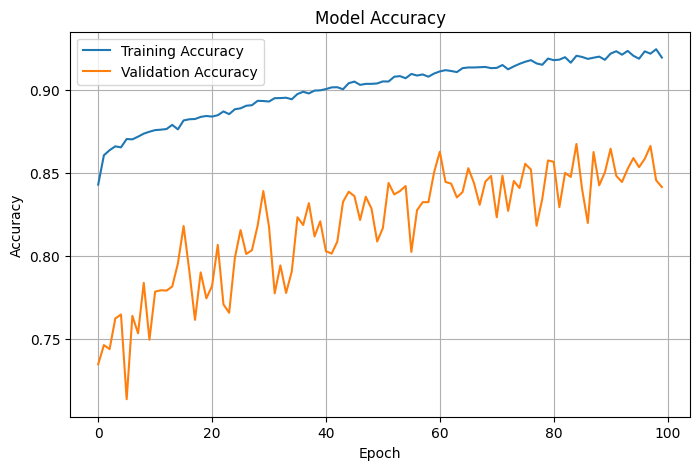

771/771 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9112 - loss: 0.2052
val loss: [0.2052146941423416, 0.9112471342086792]
val loss first number: 0.2052146941423416
Least valiation loss: 0.1840384602546692, Least loss model: <Sequential name=sequential_49, built=True>


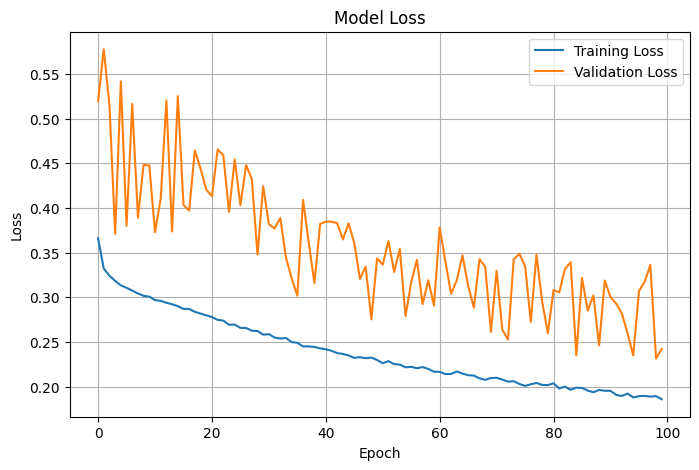

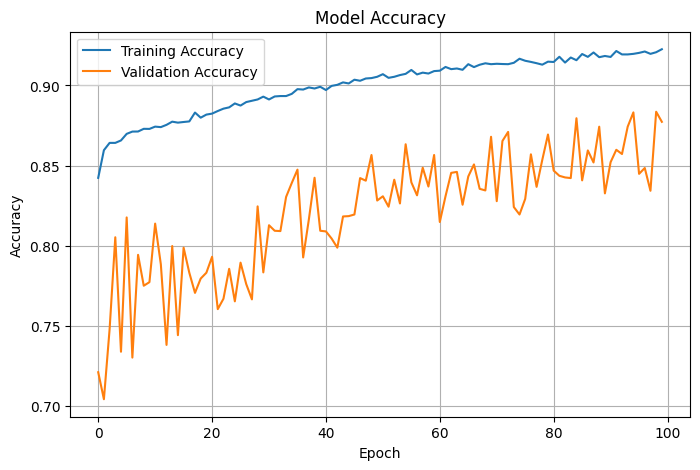

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9170 - loss: 0.1866
val loss: [0.1865547001361847, 0.9169639945030212]
val loss first number: 0.1865547001361847
Least valiation loss: 0.1840384602546692, Least loss model: <Sequential name=sequential_49, built=True>


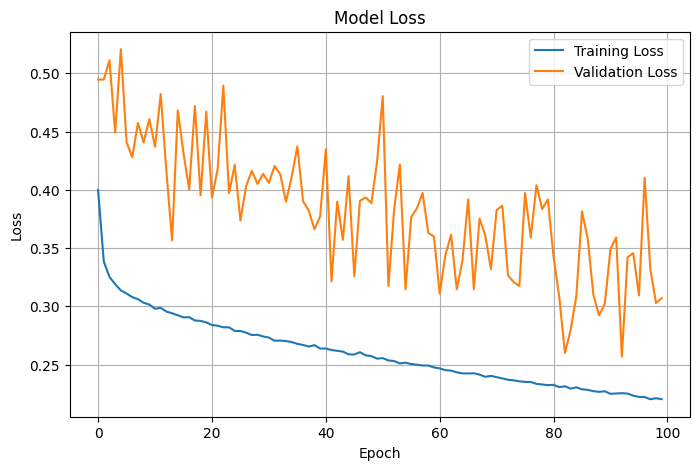

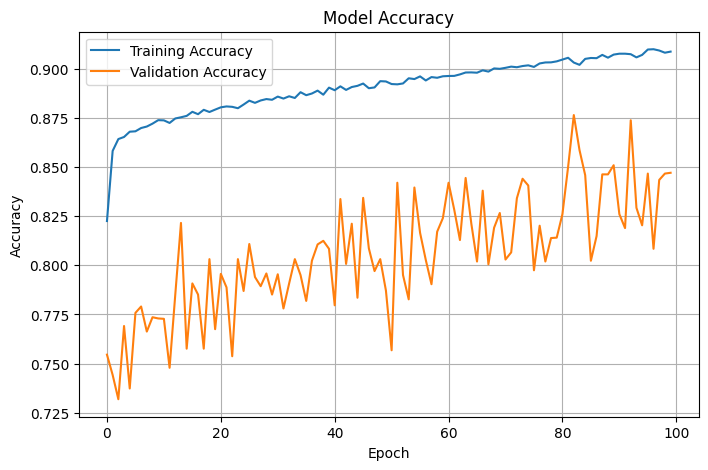

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8986 - loss: 0.2363
val loss: [0.23632501065731049, 0.8985565900802612]
val loss first number: 0.23632501065731049
Least valiation loss: 0.1840384602546692, Least loss model: <Sequential name=sequential_49, built=True>


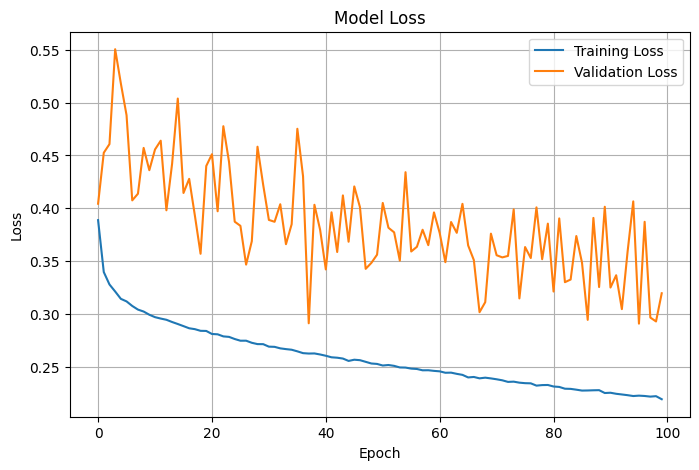

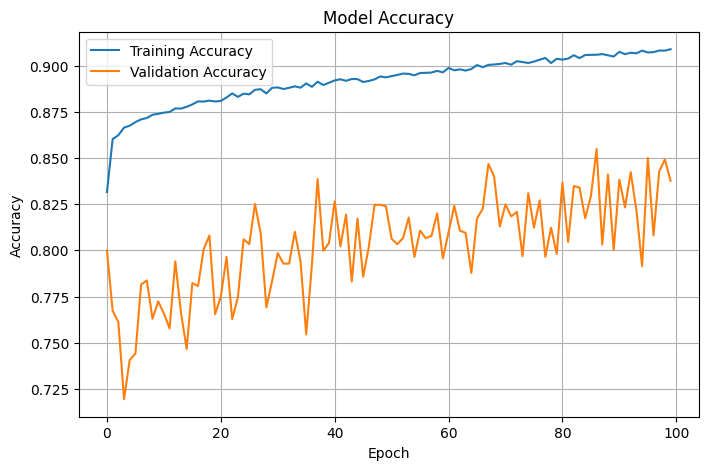

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8967 - loss: 0.2350
val loss: [0.23501650989055634, 0.8966915607452393]
val loss first number: 0.23501650989055634
Least valiation loss: 0.1840384602546692, Least loss model: <Sequential name=sequential_49, built=True>


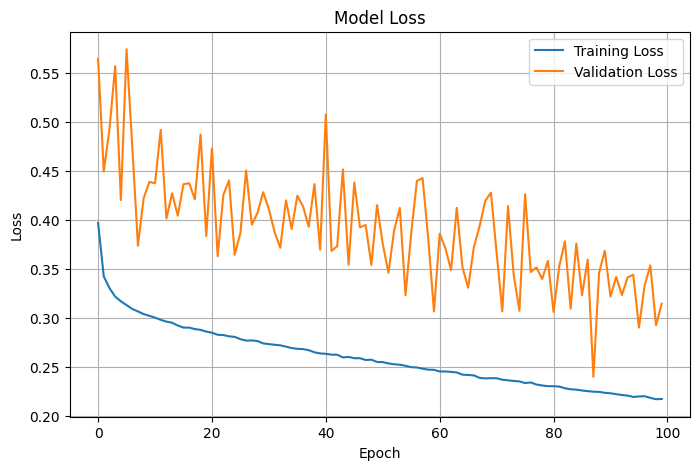

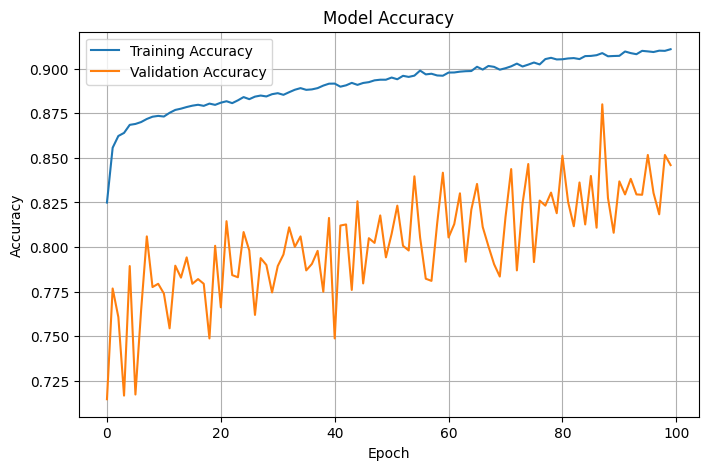

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9004 - loss: 0.2303
val loss: [0.23029032349586487, 0.900421679019928]
val loss first number: 0.23029032349586487
Least valiation loss: 0.1840384602546692, Least loss model: <Sequential name=sequential_49, built=True>


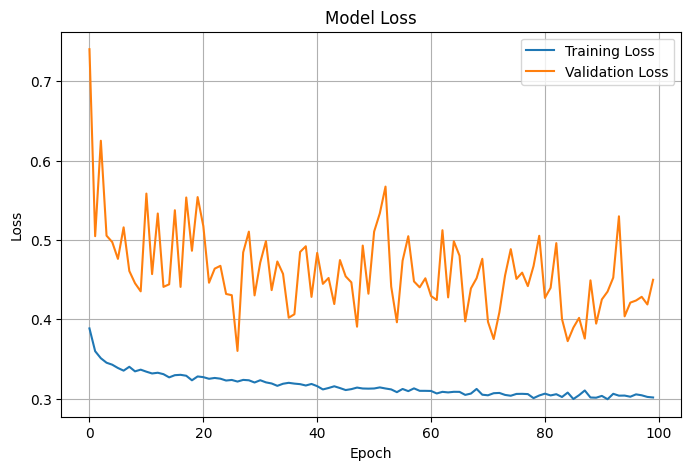

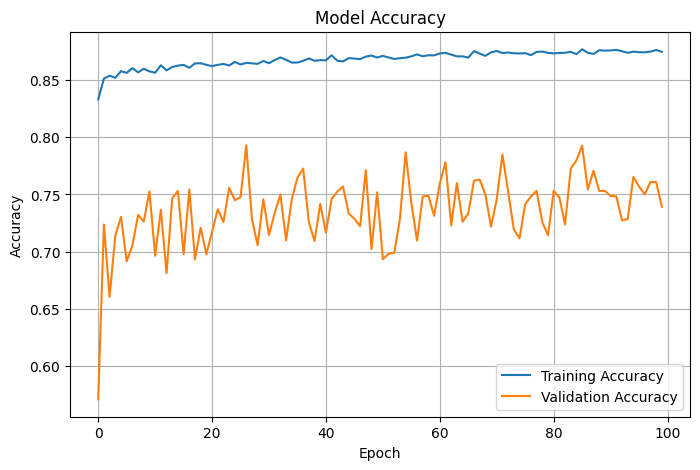

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8543 - loss: 0.3074
val loss: [0.3074032962322235, 0.854322075843811]
val loss first number: 0.3074032962322235
Least valiation loss: 0.1840384602546692, Least loss model: <Sequential name=sequential_49, built=True>


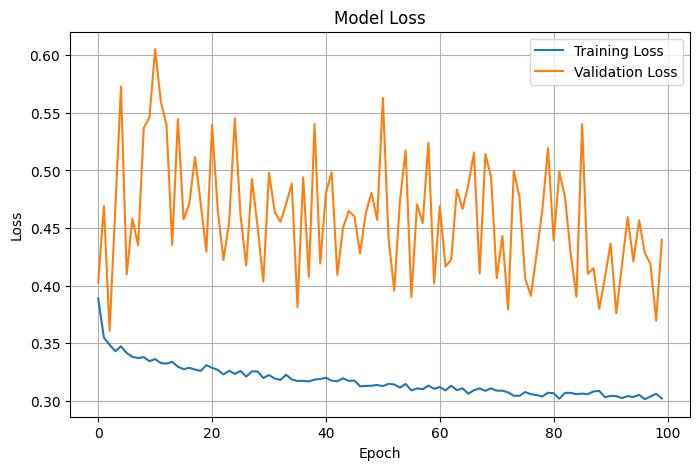

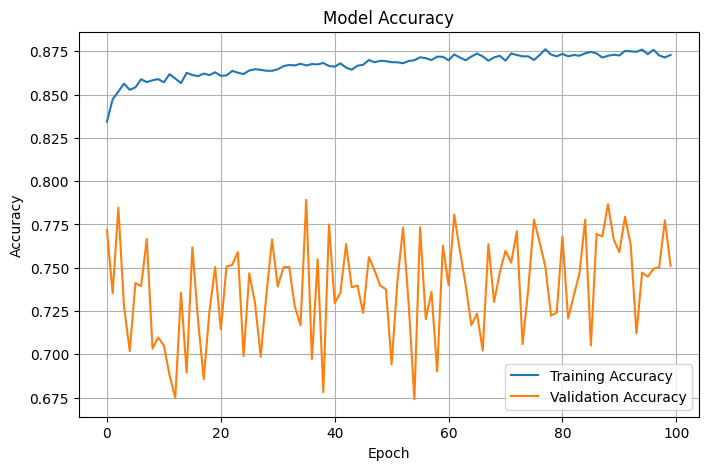

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8546 - loss: 0.3095
val loss: [0.3095361292362213, 0.8545653820037842]
val loss first number: 0.3095361292362213
Least valiation loss: 0.1840384602546692, Least loss model: <Sequential name=sequential_49, built=True>


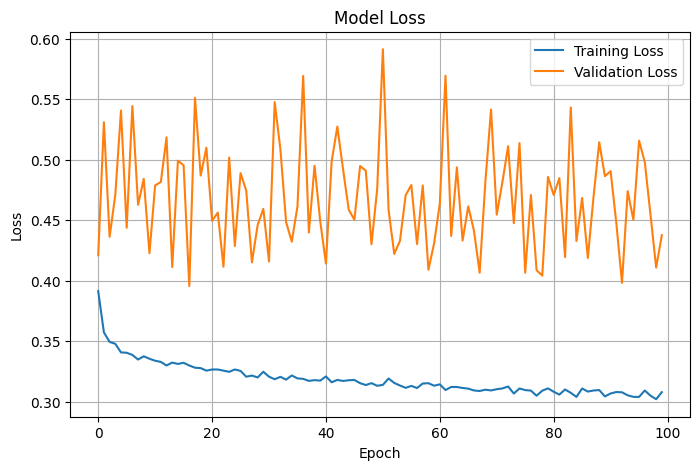

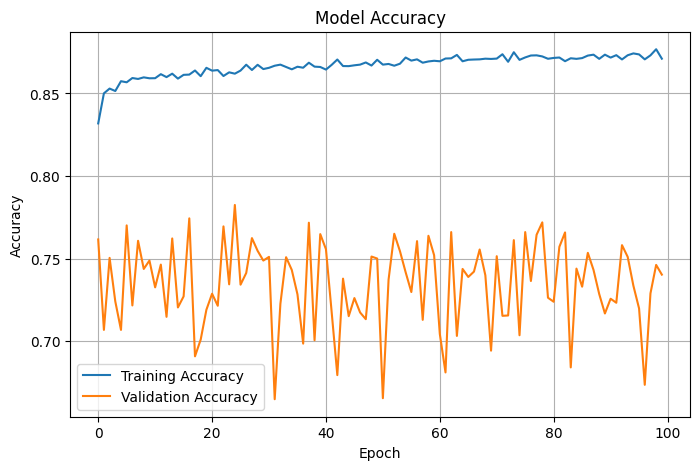

771/771 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8526 - loss: 0.3135
val loss: [0.3134961724281311, 0.8525786399841309]
val loss first number: 0.3134961724281311
Least valiation loss: 0.1840384602546692, Least loss model: <Sequential name=sequential_49, built=True>


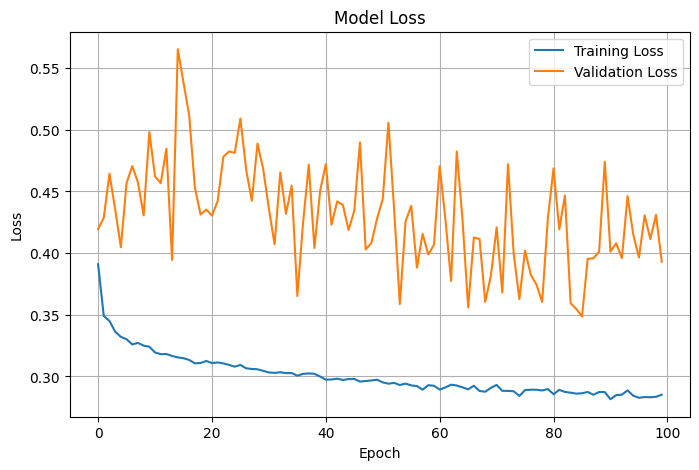

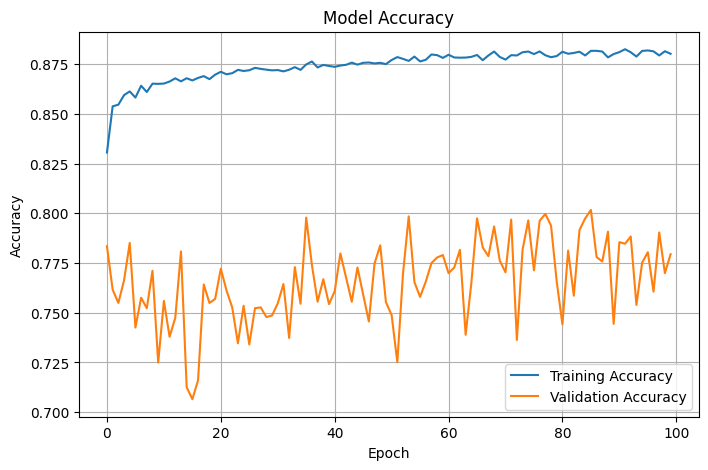

771/771 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8694 - loss: 0.2873
val loss: [0.28728601336479187, 0.8693642616271973]
val loss first number: 0.28728601336479187
Least valiation loss: 0.1840384602546692, Least loss model: <Sequential name=sequential_49, built=True>


In [ ]:
least_val_loss = float('inf')
least_loss_model = None

epochs = 100
for num_nodes in [16,32,64]:
  for dropout in [0, 0.2]:
    for learning_rate in [0.01, 0.005, 0.001]:
      for batch_size in [32,64,120]:
        history, model = train_nn_model(X_train, Y_train, num_nodes, dropout, learning_rate, batch_size, epochs)
        plot_loss(history)
        plot_accuracy(history)
        val_loss = model.evaluate(X_validation, Y_validation)
        print(f'val loss: {val_loss}')
        print(f'val loss first number: {val_loss[0]}')
        if val_loss[0] < least_val_loss:
          least_val_loss = val_loss[0]
          least_loss_model = model
        print(f'Least valiation loss: {least_val_loss}, Least loss model: {least_loss_model}')
